# 03 Modelado - Dengue Magdalena

Este notebook construye y compara modelos de pronostico de casos de dengue para el departamento del Magdalena, a partir del dataset semanal generado en el notebook 02 (dataset_modelado_magdalena.parquet), que combina los casos confirmados de SIVIGILA con las variables climáticas de la fuente ganadora por variable.

El flujo es el siguiente:

1. Carga del dataset.
2. Análisis de la serie: visualización, transformación, descomposición, estacionariedad y autocorrelación.
3. División temporal train / test.
4. Analisis de correlacion y seleccion de variables.
5. Modelos estadísticos: SARIMAX y Prophet.
6. Gradient Boosting: ingeniería de características, XGBoost y LightGBM.
7. Modelos Deep Learning: LSTM y N-BEATS
8. Comparación de todos los modelos.

# 1 Carga del dataset

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pmdarima import auto_arima

from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, ParameterGrid, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

from prophet import Prophet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scikeras.wrappers import KerasRegressor

import torch
from pytorch_lightning.callbacks import EarlyStopping as EarlyStoppingPL
from darts import TimeSeries
from darts.models import NBEATSModel

import mlflow

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS = PROJECT_ROOT / 'outputs' / 'figures' / 'model'
OUTPUTS.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlruns' / 'mlflow.db'}")
mlflow.set_experiment('dengue-magdalena')

df_dep = pd.read_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet')
df_dep['amplitud'] = df_dep['t2m_max'] - df_dep['t2m_min'] 
print(f'Shape: {df_dep.shape}')
print(f'Columnas: {df_dep.columns.tolist()}')
print(f'Anios: {sorted(df_dep["anio_epi"].unique())}')
df_dep.head()


c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (940, 10)
Columnas: ['fecha_semana', 'anio_epi', 'semana_epi', 'casos', 'humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min', 'amplitud']
Anios: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,fecha_semana,anio_epi,semana_epi,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min,amplitud
0,2006-12-31,2007,1,3,70.516907,0.165895,32.746418,27.621094,23.449194,9.297224
1,2007-01-07,2007,2,8,70.818840,0.118841,32.248680,27.119850,23.020582,9.228098
2,2007-01-14,2007,3,4,66.340004,0.081538,33.032249,27.727676,23.450821,9.581429
3,2007-01-21,2007,4,7,69.417557,0.326944,33.102013,27.605019,23.106060,9.995953
4,2007-01-28,2007,5,8,66.239731,0.120152,34.477013,28.522766,23.711058,10.765955


In [2]:
def compute_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else float('nan')
    return {
        'RMSE': round(rmse, 3),
        'MAE':  round(mae, 3),
        'MAPE': round(mape, 2),
        'R2':   round(r2, 4),
    }

def print_metrics(nombre, m):
    print(f'{nombre:35s} RMSE={m["RMSE"]:7.2f} | MAE={m["MAE"]:6.2f} | MAPE={m["MAPE"]:6.2f}% | R2={m["R2"]:6.4f}')

# 2 Análisis de la serie de tiempo

Antes de modelar se estudia la estructura de la serie de casos. Primero se visualiza la serie, luego se evalua la necesidad de estabilizar su varianza, posteriorormente se descompone la serie para evaluar la estacionalidad de la serie, luego evaluamos la estacionariedad para considerar si es necesario una diferenciacion y por ultimo miramos la autocorrelación de la serie

## 2.1 Visualización de la serie original

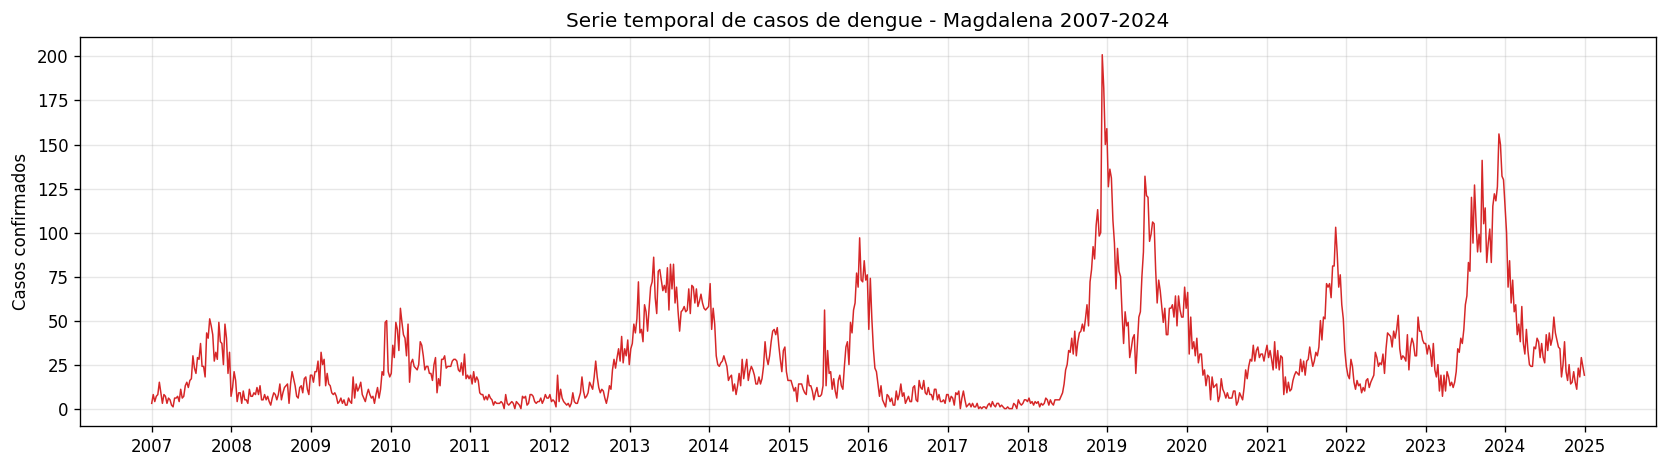

In [3]:
serie = df_dep.set_index('fecha_semana')['casos']


fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie.index, serie.values, color='#d62728', linewidth=0.9) #type: ignore
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('Casos confirmados')
ax.set_title('Serie temporal de casos de dengue - Magdalena 2007-2024')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'serie_casos.png', dpi=150, bbox_inches='tight')
plt.show()

hay un patrón anual recurrente, no un ciclo limpio. Casi todos los años muestran una subida y una bajada dentro del año, lo cual confirma componente estacional anual (s=52). Pero la fecha del pico, la altura y hasta el número de picos cambian de un año a otro. Entre temporadas altas se observan períodos de baja transmisión con valores cercanos a cero por lo que porcederemos a estabilizar su varianza

## 2.2 Estabilidad de varianza con transformación log1p

Muchos modelos estadísticos asumen varianza constante (homocedasticidad); si la varianza crece junto con el nivel de casos, esa suposición se rompe. Primero se revisa la varianza móvil sobre una ventana de 12 semanas (un trimestre): si crece en los períodos de brote, hay heterocedasticidad. Luego se aplica la transformación log(1+x) (se usa 1+x porque la serie tiene semanas con cero casos) y se compara la estabilidad del coeficiente de variación móvil de ambas series para confirmar la mejora. El análisis de las secciones siguientes se hace sobre la serie ya transformada.

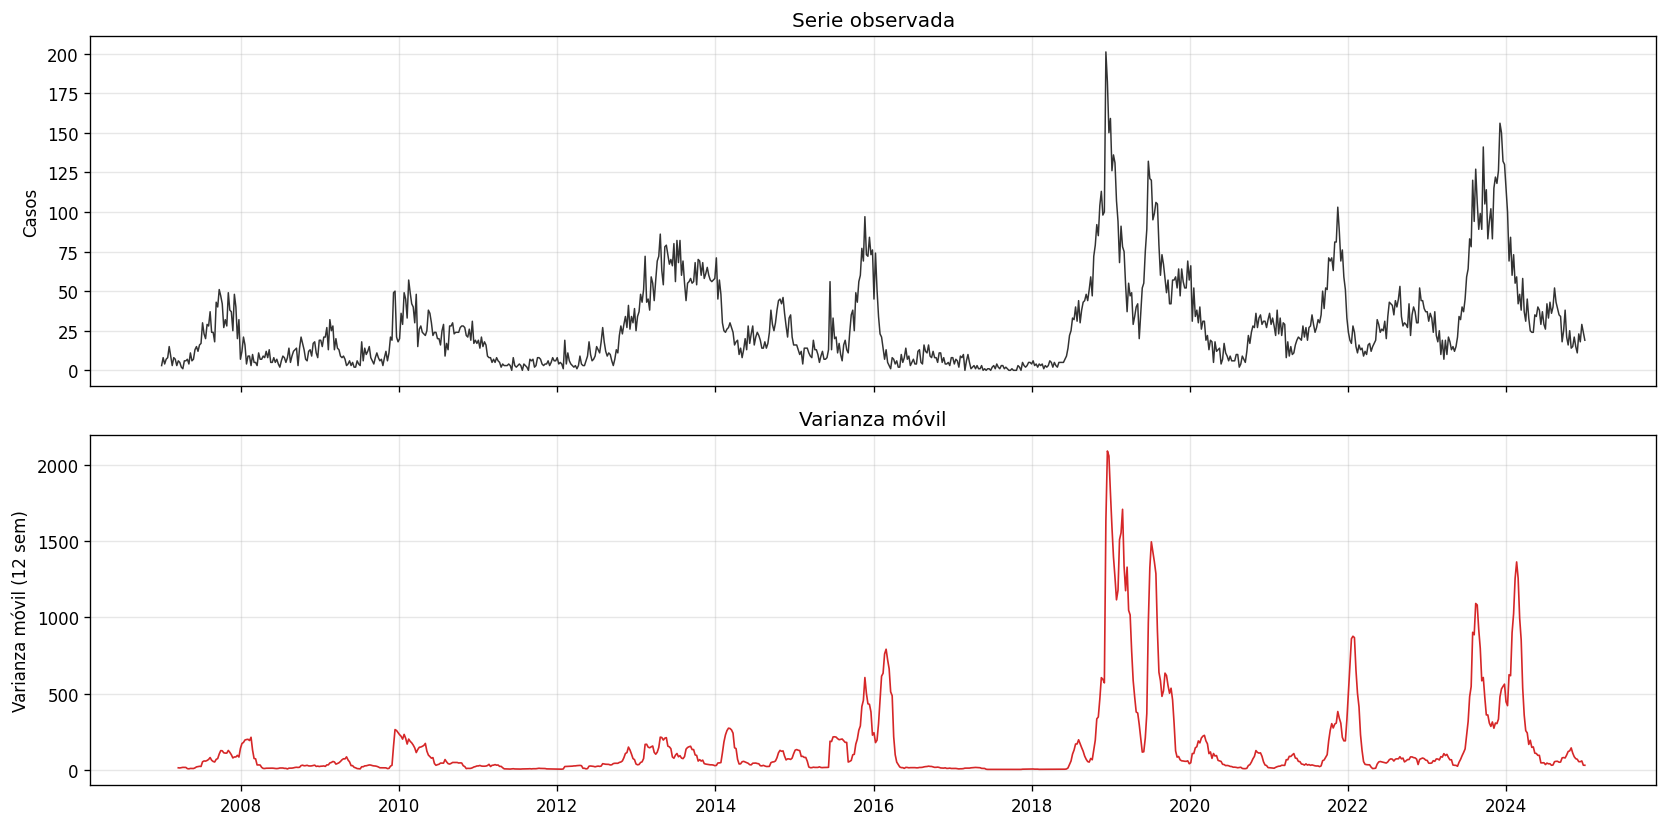

Varianza móvil mínima: 1.1
Varianza móvil máxima: 2093.9
Razón máx/mín: 1974.2


In [4]:
VENTANA = 12 
var_movil = serie.rolling(window=VENTANA).var()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(serie.index, serie.values, color='#333333', linewidth=0.9)
axes[0].set_ylabel('Casos')
axes[0].set_title('Serie observada')
axes[0].grid(alpha=0.3)

axes[1].plot(var_movil.index, var_movil.values, color='#d62728', linewidth=1.0)
axes[1].set_ylabel(f'Varianza móvil ({VENTANA} sem)')
axes[1].set_title('Varianza móvil')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'varianza_movil.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Varianza móvil mínima: {var_movil.min():.1f}')
print(f'Varianza móvil máxima: {var_movil.max():.1f}')
print(f'Razón máx/mín: {var_movil.max() / var_movil.min():.1f}')

La varianza móvil está lejos de ser constante, y cae casi a cero en los períodos de baja transmisión. La razón entre la varianza máxima y mínima supera ampliamente un orden de magnitud, lo que confirma que la serie es fuertemente heterocedástica: la dispersión crece con el nivel de casos. Esto viola el supuesto de varianza constante de los modelos estadísticos y justifica evaluar una transformación estabilizadora en la sección siguiente.

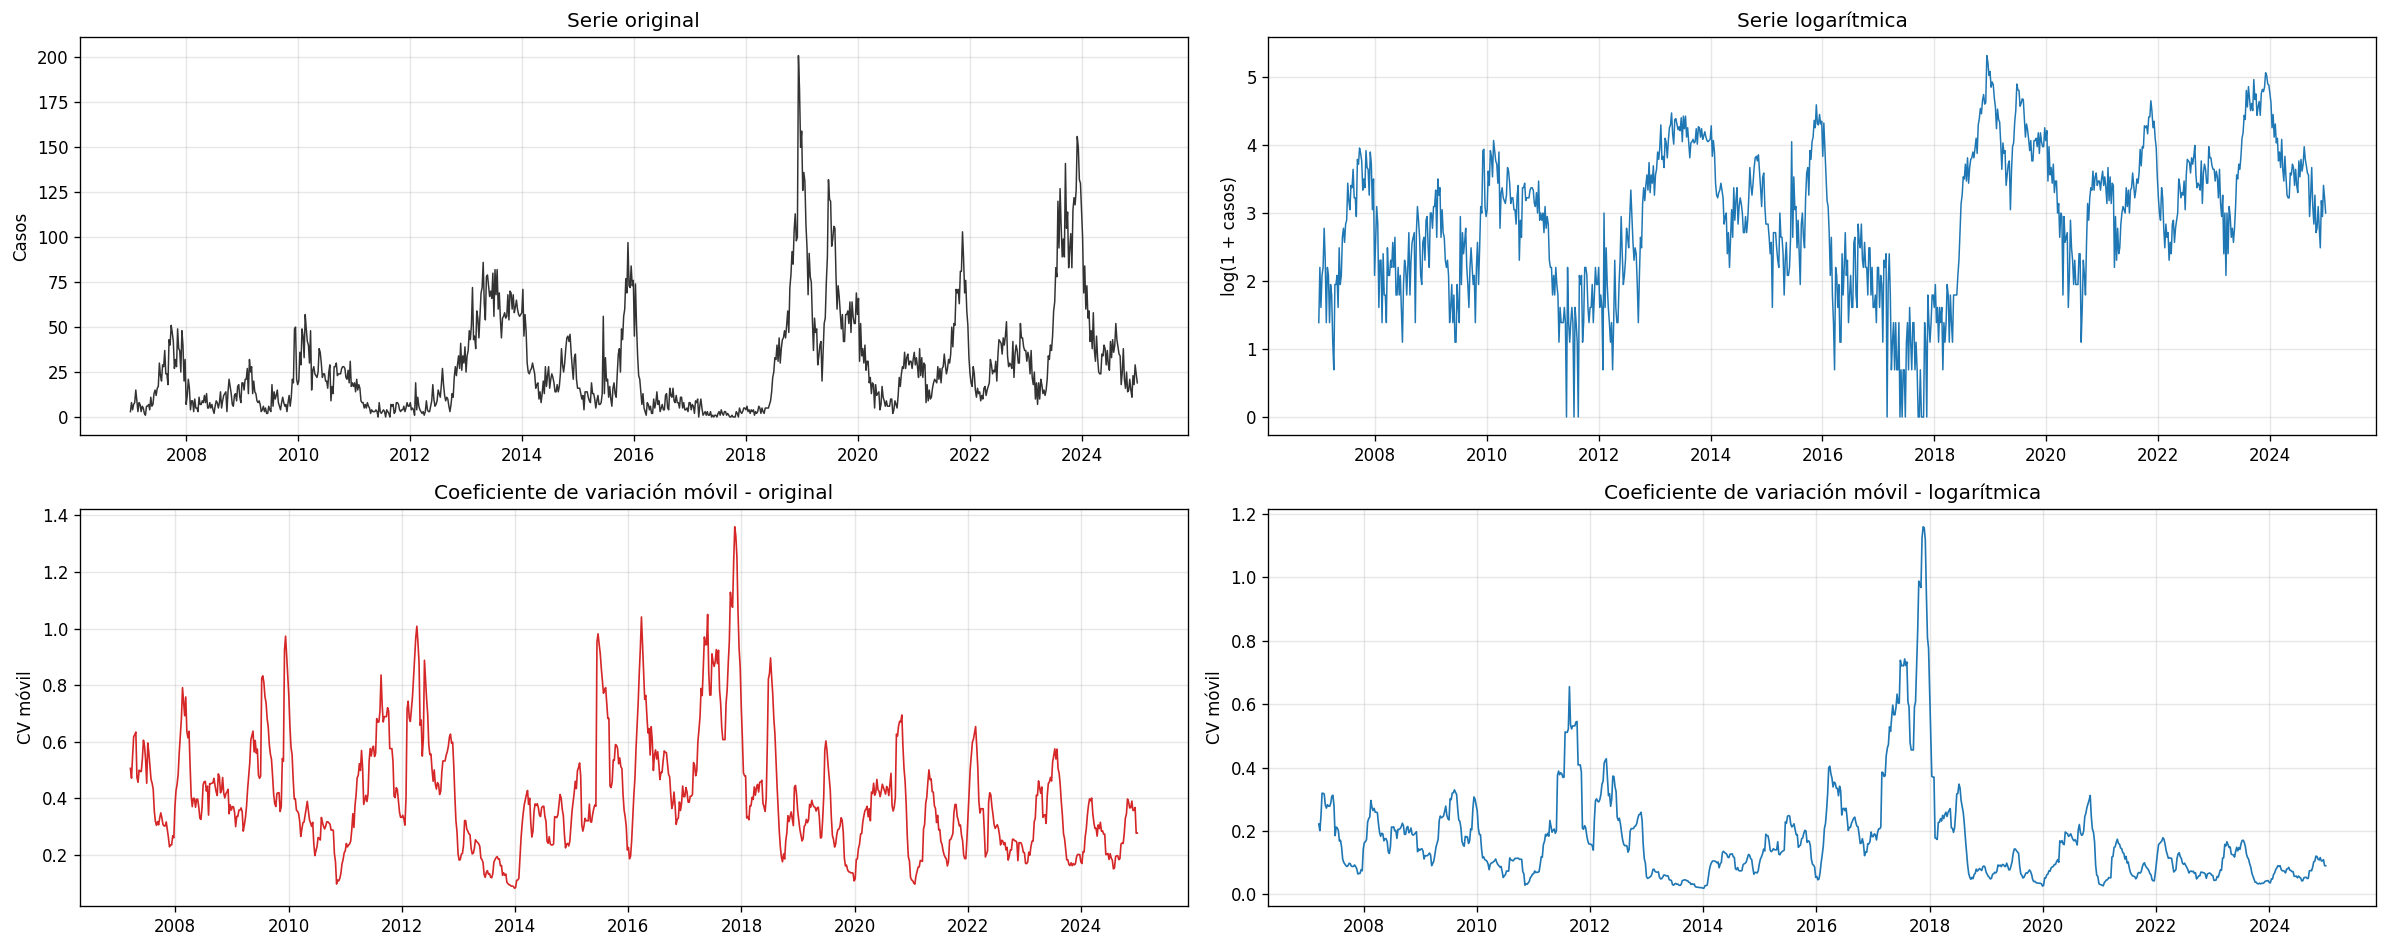

Varianza del CV móvil - original: 0.042198
Varianza del CV móvil - log: 0.024357
Reducción: 42%


In [5]:
serie_log = np.log1p(serie)

# Coeficiente de variacion movil: dispersion relativa a la media en cada ventana
def cv_movil(s, v=VENTANA):
    return (s.rolling(v).std() / s.rolling(v).mean()).dropna()

cv_orig = cv_movil(serie)
cv_log = cv_movil(serie_log)

fig, axes = plt.subplots(2, 2, figsize=(20, 8))

# Fila 1: serie original y serie logaritmica
axes[0, 0].plot(serie.index, serie.values, color='#333333', linewidth=0.9)
axes[0, 0].set_ylabel('Casos')
axes[0, 0].set_title('Serie original')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(serie_log.index, serie_log.values, color='#1f77b4', linewidth=0.9)
axes[0, 1].set_ylabel('log(1 + casos)')
axes[0, 1].set_title('Serie logarítmica')
axes[0, 1].grid(alpha=0.3)


# Fila 2: cv movil serie original y cv movil serie original logaritmica
axes[1, 0].plot(cv_orig.index, cv_orig.values, color='#d62728', linewidth=1.0)
axes[1, 0].set_ylabel('CV móvil')
axes[1, 0].set_title('Coeficiente de variación móvil - original')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cv_log.index, cv_log.values, color='#1f77b4', linewidth=1.0)
axes[1, 1].set_ylabel('CV móvil')
axes[1, 1].set_title('Coeficiente de variación móvil - logarítmica')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'comparacion_cv_movil.png', dpi=150, bbox_inches='tight')
plt.show()


print(f'Varianza del CV móvil - original: {cv_orig.var():.6f}')
print(f'Varianza del CV móvil - log: {cv_log.var():.6f}')
print(f'Reducción: {(1 - cv_log.var() / cv_orig.var()) * 100:.0f}%')

La varianza móvil de la sección anterior confirmó que la dispersión crece con el nivel de casos, pero no se puede usar directamente para comparar la serie original con la serie logarítmica ya que ambas están en escalas distintas (una en casos, la otra en log(1+casos)). Para hacer la comparación justa se usa el coeficiente de variación móvil (CV = desviación estándar / media), que es adimensional y elimina el efecto de la escala al expresar la dispersión como proporción de la media local.

La transformación logarítmica reduce la variabilidad del coeficiente de variación 
móvil respecto a la serie original, confirmando que estabiliza la dispersión. 
Adicionalmente, el patrón cíclico visible en el CV móvil de ambas series, con 
picos que se repiten aproximadamente cada 52 semanas evidencia una estacionalidad 
anual marcada, por lo que en la siguiente sección miraremos los componentes de la serie por separado para evaluar la presencia de estacionalidad.

## 2.3 Descomposición STL sobre la serie logarítmica

Se descompone la serie en tendencia, estacionalidad y ruido para entender su estructura. Conceptualmente una serie combina tendencia (comportamiento de fondo), ciclo (oscilaciones de duración variable), estacionalidad (patrón fijo, anual aquí) y ruido. En la práctica tendencia y ciclo se entregan juntos porque su separación no es identificable de forma única.

Se usa STL (Seasonal-Trend decomposition using Loess), que ajusta curvas locales suaves. Se elige sobre la descomposición clásica porque permite que el patrón estacional evolucione a lo largo de los años y es robusta frente a valores atípicos como los picos de brote. La descomposición se aplica sobre la serie logarítmica, como STL asume un modelo aditivo (Y = tendencia + estacionalidad + ruido) y la serie original es multiplicativa (la amplitud crece con el nivel), el logaritmo convierte esa relación multiplicativa en aditiva y hace válida la descomposición.

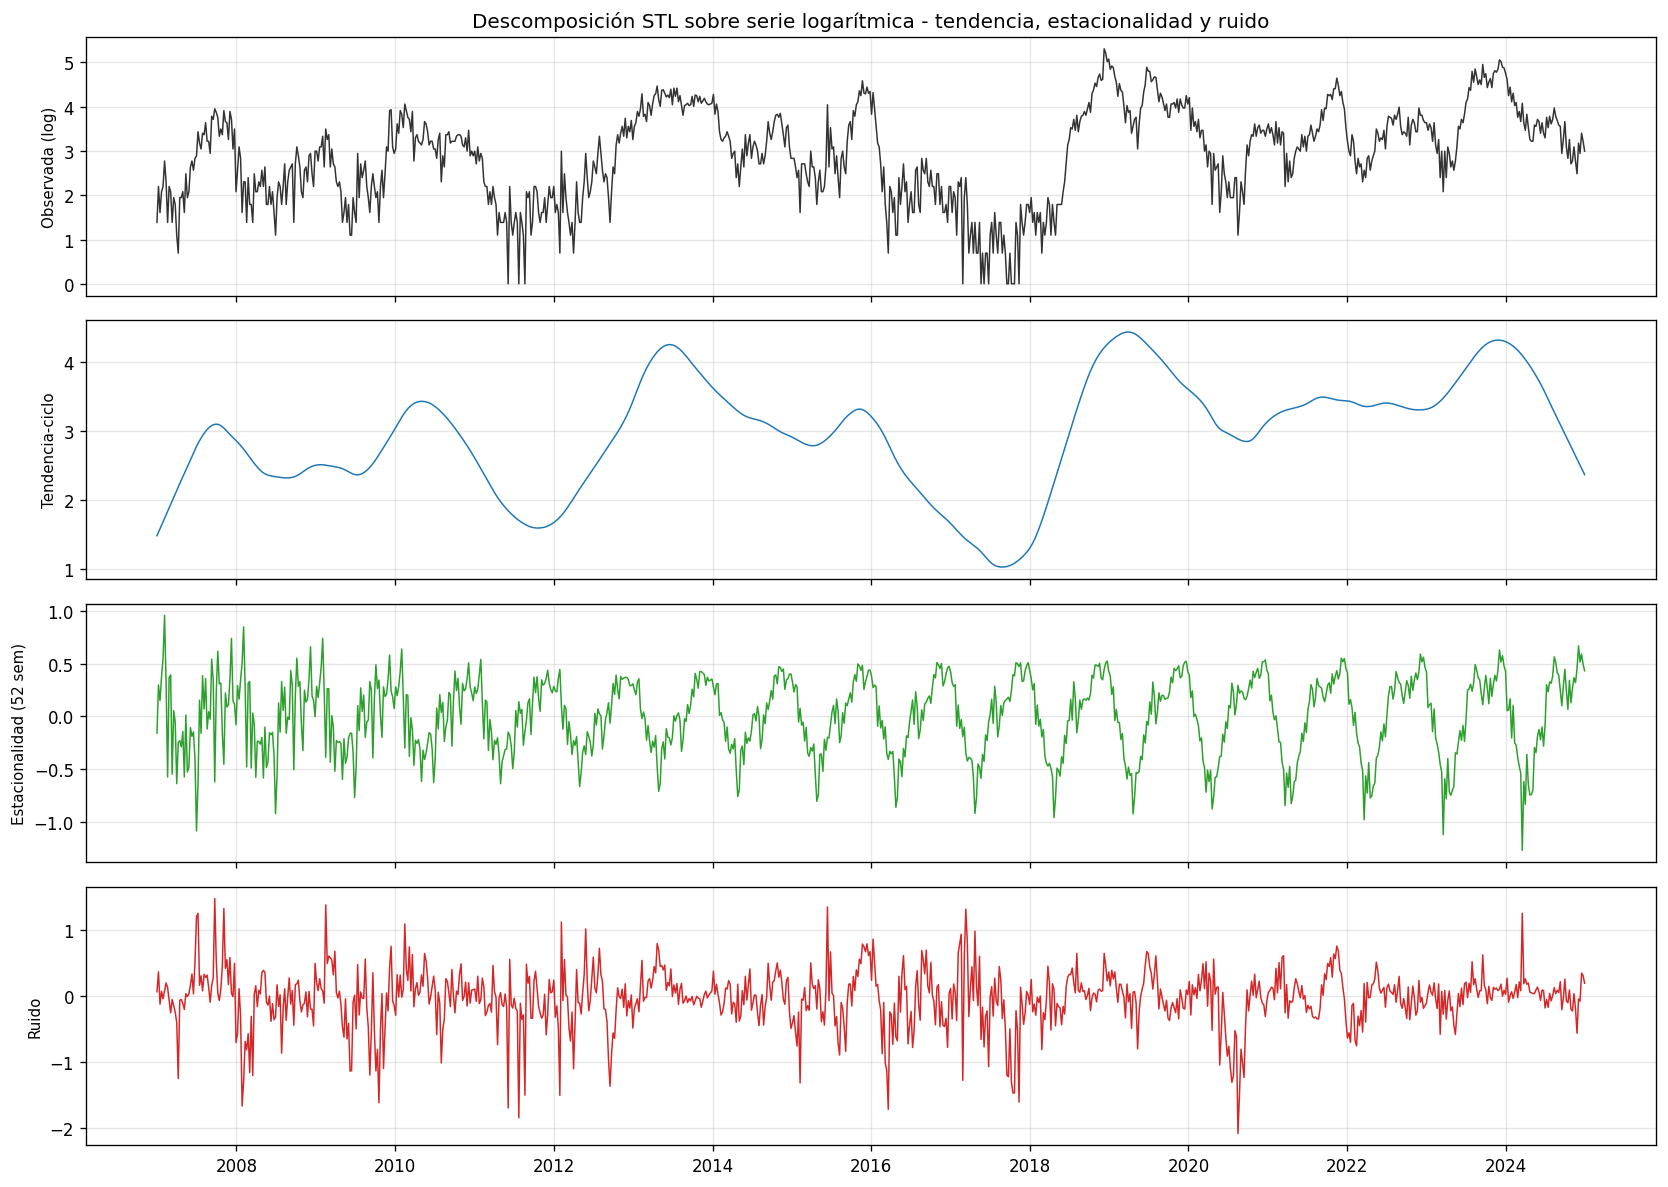

In [6]:
stl = STL(serie_log, period=52, seasonal=13, trend=53, robust=True).fit()
tendencia = stl.trend
estacionalidad = stl.seasonal
ruido = stl.resid

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
componentes = [
    (serie_log, 'Observada (log)', '#333333'),
    (tendencia, 'Tendencia-ciclo', '#1f77b4'),
    (estacionalidad, 'Estacionalidad (52 sem)', '#2ca02c'),
    (ruido, 'Ruido', '#d62728'),
]
for ax, (data, titulo, color) in zip(axes, componentes):
    ax.plot(data.index, data.values, color=color, linewidth=0.9)
    ax.set_ylabel(titulo, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_title('Descomposición STL sobre serie logarítmica - tendencia, estacionalidad y ruido')
plt.tight_layout()
plt.savefig(OUTPUTS / 'descomposicion_serie.png', dpi=150, bbox_inches='tight')
plt.show()

La descomposición confirma una estacionalidad anual marcada y estable en su forma, con un ciclo de 52 semanas que se repite cada año, lo que respalda el uso de terminos estacionales en los modelos.

El residuo se mantiene centrado en cero y sin estructura estacional remanente, lo que indica que la descomposicion extrajo bien la componente anual. Sin embargo conserva una varianza considerable, con picos puntuales a lo largo de toda la serie atribuibles a brotes atipicos o anomalias de reporte. Esta varianza no explicada por tendencia y estacionalidad motiva la inclusion de covariables climaticas y terminos autorregresivos en el modelado. El tramo final de la tendencia muestra una caida pronunciada que podria estar influenciada por el efecto de borde del suavizado loess, dado que en los extremos de la serie hay menos datos disponibles.

Ahora evaluaremos si la serie es estacionaria.

## 2.4 Pruebas de estacionariedad (ADF, KPSS)

Una serie es estacionaria cuando sus propiedades estadísticas (media, varianza, autocorrelación) no cambian con el tiempo. La mayoría de modelos ARIMA exigen estacionariedad, por lo que se verifica y, si no se cumple, se aplica diferenciación.

Se usan dos pruebas complementarias. ADF (Augmented Dickey-Fuller) tiene como hipótesis nula que la serie NO es estacionaria; un p-valor menor a 0.05 permite concluir estacionariedad. KPSS tiene la hipótesis nula contraria; aquí un p-valor menor a 0.05 lleva a rechazar la estacionariedad. La conclusión más confiable se da cuando ambas coinciden. Las pruebas se aplican sobre la serie logarítmica, su diferencia regular y su diferencia estacional, para sustentar la elección de d y D con evidencia. Es importante distinguir estacionariedad de estacionalidad: ADF y KPSS detectan tendencia estocástica pero no miden el patrón estacional.

In [7]:
def run_adf(serie):
    stat, p, _, _, crit, _ = adfuller(serie.dropna(), autolag='AIC')  # type: ignore
    return p, ('Estacionaria' if p < 0.05 else 'No estacionaria')

def run_kpss(serie):
    stat, p, _, crit = kpss(serie.dropna(), regression='c', nlags='auto')
    return p, ('No estacionaria' if p < 0.05 else 'Estacionaria')

def evaluar(serie, nombre):
    p_adf, c_adf = run_adf(serie)
    p_kpss, c_kpss = run_kpss(serie)
    return {
        'Serie': nombre,
        'ADF p-valor': round(p_adf, 4), 'ADF': c_adf,  # type: ignore
        'KPSS p-valor': round(p_kpss, 4), 'KPSS': c_kpss,
        'Estacionaria (ambas)': (c_adf == 'Estacionaria') and (c_kpss == 'Estacionaria'),
    }


df_stationarity = pd.DataFrame([
    evaluar(serie_log, 'Log sin diferenciar'),
    evaluar(serie_log.diff(), 'Log diff regular (d=1)'),
])
print(df_stationarity.to_string(index=False))

                 Serie  ADF p-valor          ADF  KPSS p-valor            KPSS  Estacionaria (ambas)
   Log sin diferenciar       0.0014 Estacionaria        0.0107 No estacionaria                 False
Log diff regular (d=1)       0.0000 Estacionaria        0.1000    Estacionaria                  True


Las pruebas confirman que la serie log no es estacionaria por lo que se aplicara la primera diferenciacion (d=1).

## 2.5 ACF / PACF - identificación de órdenes

Se analiza la estructura de autocorrelación de la serie logarítmica para orientar la selección de los órdenes p, q, P y Q. La ACF (Función de Autocorrelación) mide la correlación de la serie con versiones retrasadas de sí misma y orienta los órdenes de media móvil q y Q. La PACF (Función de Autocorrelación Parcial) mide la correlación con cada lag eliminando el efecto de los intermedios y orienta los órdenes autorregresivos p y P.

In [8]:
serie_log_diff = serie_log.diff()

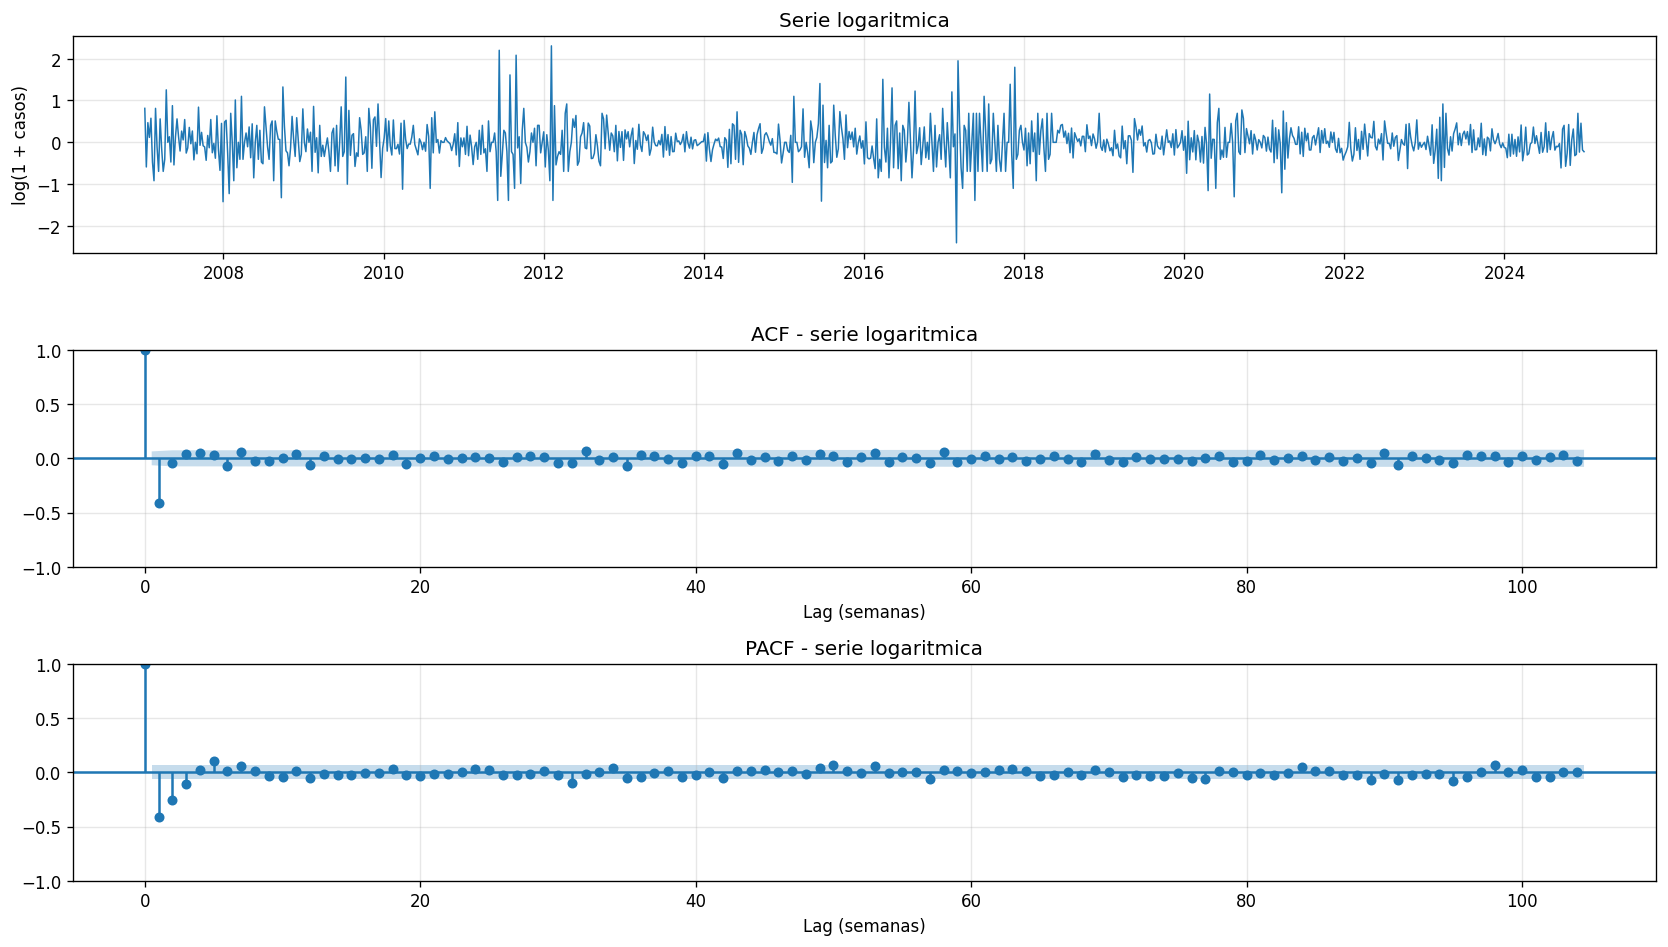

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# subplot 0 - serie original
axes[0].plot(serie_log_diff.index, serie_log_diff.values, color='#1f77b4', linewidth=0.9)
axes[0].set_ylabel('log(1 + casos)')
axes[0].set_title('Serie logaritmica')
axes[0].grid(alpha=0.3)

# subplot 1 - ACF
plot_acf(serie_log_diff.dropna(), lags=104, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF - serie logaritmica')
axes[1].set_xlabel('Lag (semanas)')
axes[1].grid(alpha=0.3)

# subplot 2 - PACF
plot_pacf(serie_log_diff.dropna(), lags=104, ax=axes[2], alpha=0.05, method='ywm')
axes[2].set_title('PACF - serie logaritmica')
axes[2].set_xlabel('Lag (semanas)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

La PACF presenta 4 rezagos significativos (lag 1 cercano a -0.5, lag 2 alrededor de -0.3, lag 3 -0.1 y lag 5 0.1)por lo que se fija p = [1,2,3,5]. La ACF decae con un corte abrupto en el lag 1, por lo que se parte de q = 1. Las pruebas de la sección 2.4 ya confirmaron estacionariedad con la primera diferenciacion, de modo que d = 1.

Para los ordenes estacionales, ni ACF ni PACF muestran picos aislados significativos en los multiplos de 52 por lo que P = 0 y Q = 0. El periodo estacional se fija en s = 52, correspondiente al ciclo anual de semanas epidemiologicas, y se incorpora mediante la extension estacional del modelo, es decir SARIMA(p,d,q)(P,D,Q,52)

El ciclo anual del dengue de 52 semanas está documentado en la literatura. Zhao et al., trabajando con datos de SIVIGILA en Colombia, incorporan el número ordinal de semana epidemiológica (1 a 52) como predictor explícito para capturar la estacionalidad de la transmisión. Sobre esta base, el componente estacional se incluye en el modelo por justificación epidemiológica y por la evidencia de la descomposición, y no únicamente por el correlograma, cuya capacidad para exhibir estructura estacional es limitada en series cortas con autocorrelación de corto plazo dominante.

Los valores p = [1,2,3,5], q = 1, P = 0, Q = 0 y s = 52 constituyen el punto de partida obtenido por identificación manual. En la seccion 5 se usa auto_arima, con d = 1 y D = 0 fijos segun lo confirmado en la seccion 2.4 y s = 52 fijo, para explorar de forma sistematica el espacio de ordenes alrededor de esta propuesta y confirmar o ajustar p, q, P y Q con base en un criterio de informacion (AIC o BIC).

# 3 Division temporal train / val / test

La serie se divide en tres bloques cronologicos contiguos respetando el orden temporal, sin barajar. El primer 70 por ciento es entrenamiento, el 15 por ciento siguiente es validacion y el 15 por ciento final es prueba. El conjunto de prueba es el mismo para todos los modelos y solo se usa una vez por modelo, lo que mantiene la comparacion de la seccion 8 libre de fuga de informacion.

El conjunto de validacion no lo necesitan todos los modelos por igual. SARIMAX y Prophet fijan su estructura por criterios de informacion, no por una busqueda sobre validacion, y los modelos de arboles seleccionan sus hiperparametros con validacion cruzada temporal sobre el bloque de entrenamiento ampliado. Por eso estos cuatro modelos entrenan con train mas val (85 por ciento) y predicen el test, lo que ademas evita un hueco temporal entre el fin del entrenamiento y el inicio del test. La validacion separada solo la usan las redes neuronales (seccion 7) para el early stopping.

Train:  658 sem (2006-2019) | 70.0%
Val  :  141 sem (2019-2022) | 15.0%
Test :  141 sem (2022-2024) | 15.0%
Train+Val:  799 sem | 85.0%


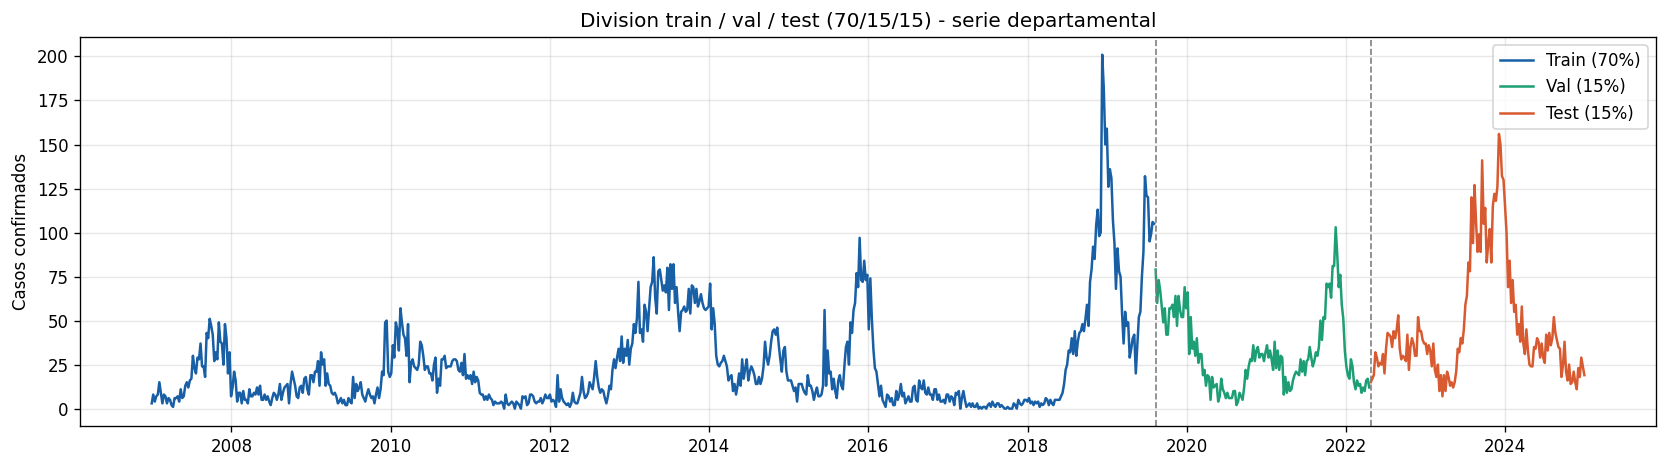

In [10]:
TRAIN_FRAC, TEST_FRAC = 0.70, 0.30
n = len(df_dep)
n_resto = round(n * TEST_FRAC)

idx_train, idx_resto = list(TimeSeriesSplit(n_splits=2, test_size=n_resto).split(df_dep))[-1]

df_train_dep = df_dep.iloc[idx_train].copy()
df_resto = df_dep.iloc[idx_resto].copy()

# El 30% restante se parte en dos mitades cronologicas iguales: validacion y test.
n_val = len(df_resto) // 2
df_val_dep = df_resto.iloc[:n_val].copy()
df_test_dep = df_resto.iloc[n_val:].copy()

# Conjuntos de fechas para alinear cualquier dataset derivado de df_dep.
FECHAS_TRAIN = set(df_train_dep['fecha_semana'])
FECHAS_VAL = set(df_val_dep['fecha_semana'])
FECHAS_TEST = set(df_test_dep['fecha_semana'])

# train + val (85%): bloque de entrenamiento para los modelos que no reservan
# una validacion aparte. Llega contiguo hasta justo antes del test.
df_trainval_dep = pd.concat([df_train_dep, df_val_dep]).sort_values('fecha_semana')
FECHAS_TRAINVAL = FECHAS_TRAIN | FECHAS_VAL

for nombre, d in [('Train', df_train_dep), ('Val', df_val_dep), ('Test', df_test_dep)]:
    print(f'{nombre:5s}: {len(d):4d} sem ({d["fecha_semana"].dt.year.min()}-{d["fecha_semana"].dt.year.max()}) | {len(d) / n:.1%}')
print(f'Train+Val: {len(df_trainval_dep):4d} sem | {len(df_trainval_dep) / n:.1%}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train_dep['fecha_semana'], df_train_dep['casos'], color='#185FA5', label='Train (70%)')
ax.plot(df_val_dep['fecha_semana'], df_val_dep['casos'], color='#1D9E75', label='Val (15%)')
ax.plot(df_test_dep['fecha_semana'], df_test_dep['casos'], color='#D85A30', label='Test (15%)')
ax.axvline(df_val_dep['fecha_semana'].iloc[0], color='gray', linewidth=1, linestyle='--')
ax.axvline(df_test_dep['fecha_semana'].iloc[0], color='gray', linewidth=1, linestyle='--')
ax.set_ylabel('Casos confirmados')
ax.set_title('Division train / val / test (70/15/15) - serie departamental')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'train_val_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

# 4 Análisis de correlación y selección de variables

Antes de decidir qué variables climáticas alimentan los modelos se estudia su comportamiento y su relación con el objetivo. Todo el análisis se hace sobre el bloque de entrenamiento (train+val), sin mirar el test, para que la selección de características no filtre información. Primero se revisa la distribución de cada variable para elegir el coeficiente de correlación adecuado, luego la redundancia entre predictores (multicolinealidad) y por último la relación con los casos, incluyendo rezagos, ya que el clima actúa sobre la transmisión con retardo.

## 4.1 Distribución de las variables

La elección entre Pearson y Spearman depende de la forma de los datos. Pearson mide asociación lineal y es sensible a la asimetría y a los valores extremos; Spearman trabaja sobre rangos, por lo que es robusto a distribuciones sesgadas y capta cualquier relación monótona, no solo la lineal. Se examina la forma de cada distribución con histogramas para sustentar la elección.

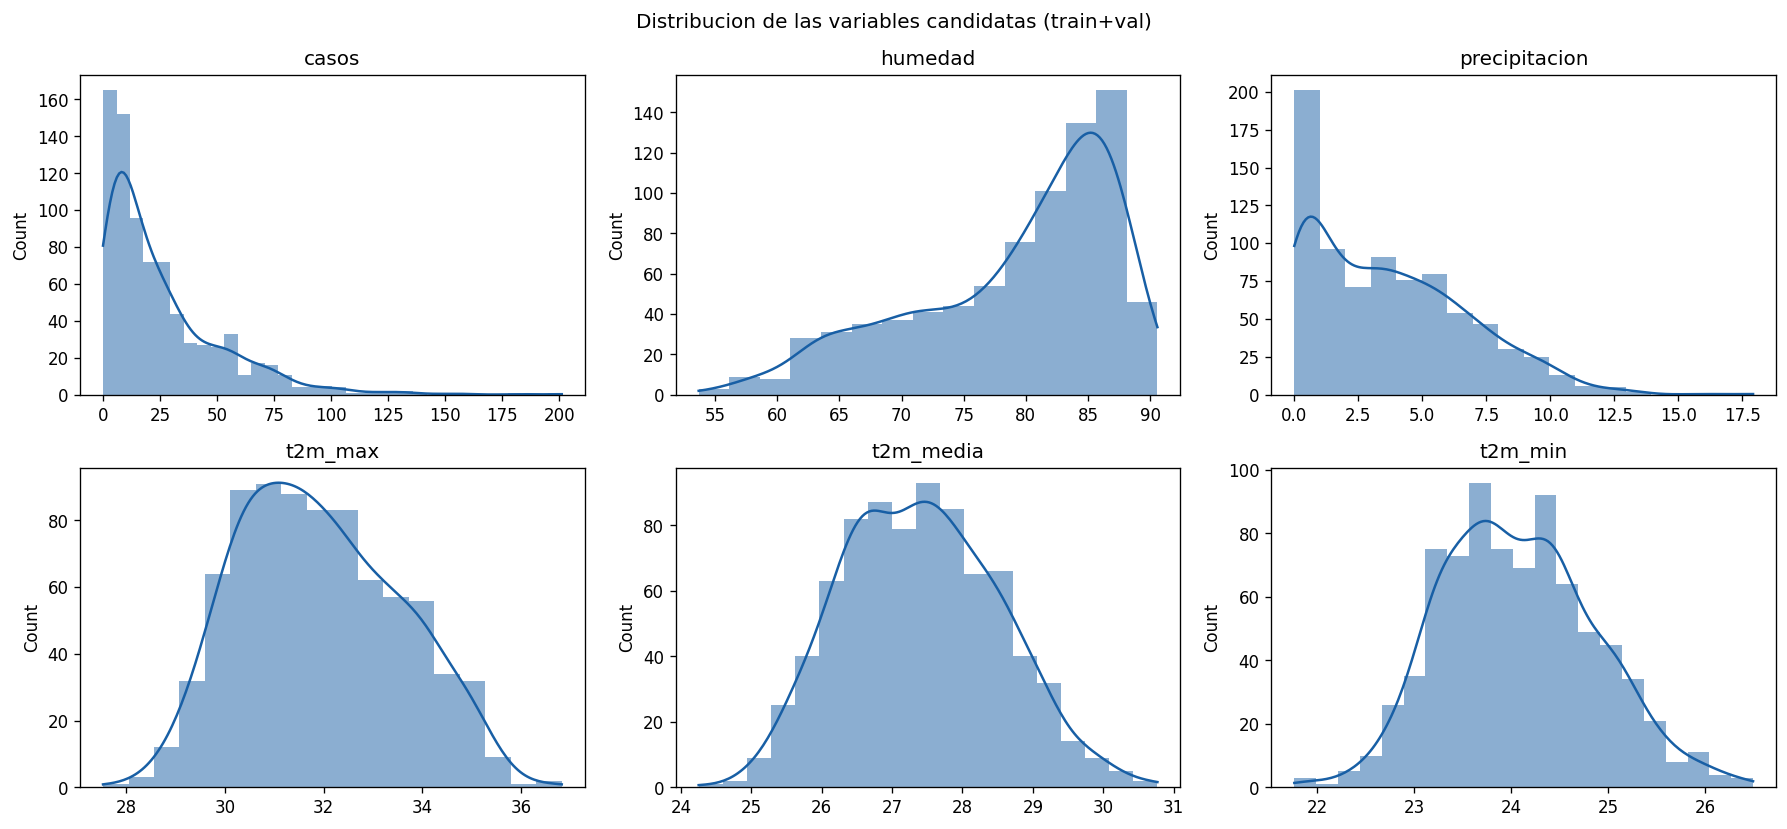

In [11]:
CLIMA = ['humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min']
VARS_SEL = ['casos'] + CLIMA

# Diagnostico sobre el bloque de entrenamiento (train+val), sin tocar el test.
df_sel = df_trainval_dep[VARS_SEL].astype(float)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, v in zip(axes.ravel(), VARS_SEL):
    sns.histplot(df_sel[v], kde=True, ax=ax, color='#185FA5', edgecolor='none')
    ax.set_title(v)
    ax.set_xlabel('')
plt.suptitle('Distribucion de las variables candidatas (train+val)')
plt.tight_layout()
plt.savefig(OUTPUTS / 'distribucion_variables.png', dpi=150, bbox_inches='tight')
plt.show()

Ninguna variable se ve normal en los histogramas: los casos están muy sesgados a la derecha y la humedad hacia la izquierda. Por esa asimetría, y por su capacidad de detectar relaciones monótonas no lineales, se usa Spearman en todo el análisis de correlación.

## 4.2 Multicolinealidad entre predictores

Las variables climáticas tienden a moverse juntas (más calor suele venir con menos humedad). Cuando dos predictores aportan casi la misma información, los modelos lineales como SARIMAX reparten el efecto de forma inestable y sus coeficientes dejan de ser interpretables; los modelos de árboles lo toleran mejor, pero igual ganan en parsimonia. Se cuantifica con la matriz de Spearman y con el factor de inflación de varianza (VIF), que mide cuánto crece la varianza de un predictor por su colinealidad con el resto (VIF > 10 indica redundancia alta).

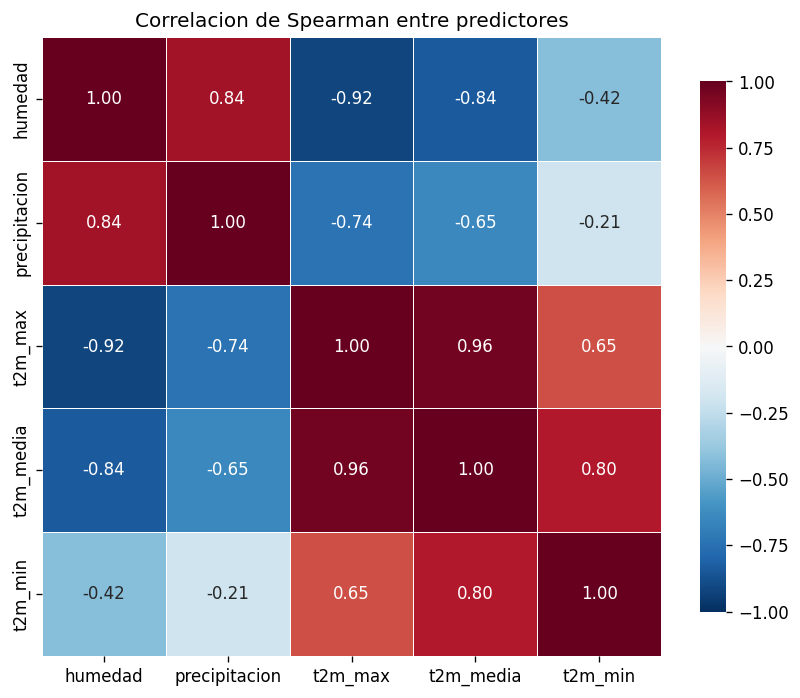

     Variable     VIF
    t2m_media 50810.0
      t2m_max 17122.4
      t2m_min 13467.2
      humedad   240.3
precipitacion     6.4


In [12]:

corr_sp = df_sel[CLIMA].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_sp, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlacion de Spearman entre predictores')
plt.tight_layout()
plt.savefig(OUTPUTS / 'correlacion_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

X_vif = df_sel[CLIMA].values
vif = pd.DataFrame({
    'Variable': CLIMA,
    'VIF': [round(variance_inflation_factor(X_vif, i), 1) for i in range(len(CLIMA))],
}).sort_values('VIF', ascending=False)
print(vif.to_string(index=False))

Las tres variables de temperatura son casi intercambiables (VIF de miles y ρ entre 0.65 y 0.96 entre ellas), y la humedad está muy correlacionada con la temperatura (ρ = -0.92 con t2m_max). Solo la precipitación tiene un VIF bajo (6.4), es decir, aporta información propia. En consecuencia se reconstruye el conjunto de predictores en la siguiente sección.

## 4.2.1 Reconstrucción del set de predictores

Con el diagnóstico se redefine el conjunto climático. La precipitación se conserva: es la única con VIF bajo y sin colinealidad con la temperatura, aporta información propia y regula los criaderos del vector. Las tres temperaturas son casi la misma señal, así que se resumen en nivel (t2m_media) y amplitud térmica (amplitud = t2m_max - t2m_min), y se eliminan t2m_max y t2m_min; la amplitud térmica diurna tiene además respaldo biológico en la transmisión del dengue. La humedad se descarta por su redundancia con la temperatura (ρ = -0.92) y su señal débil frente a los casos. Se recalculan VIF y Spearman sobre el nuevo conjunto.

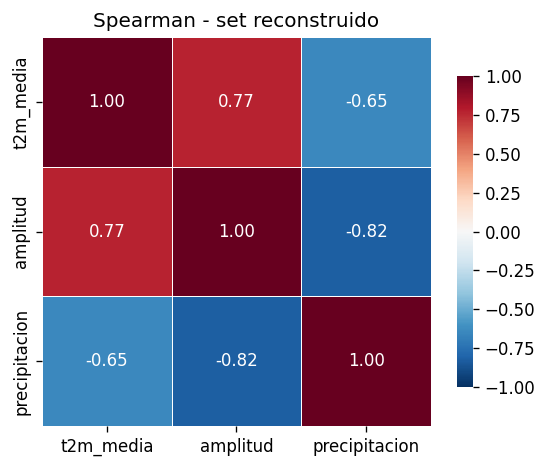

     Variable   VIF
    t2m_media 137.8
     amplitud 112.1
precipitacion   4.6


In [13]:
CLIMA = ['t2m_media', 'amplitud', 'precipitacion']

# Bandera de normalidad (Shapiro) del set final, usada en el resumen (4.4).
df_norm = pd.DataFrame({
    'Variable': CLIMA,
    'Normal': ['si' if stats.shapiro(df_trainval_dep[v])[1] > 0.05 else 'no' for v in CLIMA],
})

corr_sp = df_trainval_dep[CLIMA].corr(method='spearman')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_sp, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Spearman - set reconstruido')
plt.tight_layout()
plt.savefig(OUTPUTS / 'correlacion_spearman_final.png', dpi=150, bbox_inches='tight')
plt.show()

X_vif = df_trainval_dep[CLIMA].values
vif = pd.DataFrame({
    'Variable': CLIMA,
    'VIF': [round(variance_inflation_factor(X_vif, i), 1) for i in range(len(CLIMA))],
}).sort_values('VIF', ascending=False)
print(vif.to_string(index=False))

La reconstrucción elimina la redundancia extrema del trío de temperatura: el VIF baja de decenas de miles a un orden de ~100. La precipitación queda con VIF bajo. Media y amplitud siguen algo correlacionadas (ρ ≈ 0.76), por lo que su VIF no cae por debajo de 10, pero el conjunto es mucho más parsimonioso e interpretable que el original. Para los modelos lineales, si se busca VIF < 10, basta conservar una sola representante de temperatura; esas combinaciones se prueban en SARIMAX.

# 5 Modelos estadísticos

Este bloque agrupa los modelos estadísticos clásicos de series de tiempo. La familia ARIMA combina tres componentes: una parte autorregresiva (AR) que usa los valores pasados de la serie, una parte de integración o diferenciación (I) que elimina tendencias para alcanzar estacionariedad, y una parte de media móvil (MA) que usa los errores pasados. Sus extensiones añaden capacidades: SARIMA incorpora una componente estacional con período fijo, y SARIMAX agrega además variables exógenas (la X de eXogenous), predictores externos que influyen en la serie sin formar parte de ella.

A partir del análisis de la sección 2 (estacionariedad confirmada con d = 1, estacionalidad anual respaldada por la descomposición STL y la literatura, y disponibilidad de variables climáticas) se trabaja directamente con SARIMAX como modelo de esta familia, por ser la formulación que aprovecha toda la estructura encontrada. Se complementa con Prophet, un modelo de naturaleza distinta que sirve como comparador.

Los modelos estadísticos reciben como entrada la serie logarítmica serie_log. 
La diferenciación de orden d=1 se aplica internamente por statsmodels y se 
revierte automáticamente en el forecast. Las predicciones se transforman a 
escala de casos con np.expm1 antes de calcular las métricas, de modo que los errores se reporten en la unidad interpretable (casos).

## 5.1 Familia ARIMA y extensiones: SARIMAX

La eleccion de SARIMAX se sustenta en lo encontrado a lo largo del analisis. Las pruebas ADF y KPSS de la seccion 2.4 confirmaron que la serie logaritmica se vuelve estacionaria al aplicar la primera diferenciacion, por lo que se fija d = 1. La lectura de la PACF acota el orden autorregresivo y la de la ACF sugiere el orden de media movil como punto de partida. La estacionalidad anual, no visible en el correlograma por las razones expuestas en 2.5 pero clara en la descomposicion STL y documentada por Zhao et al. para datos de SIVIGILA en Colombia, se modela con los terminos estacionales sobre un periodo s = 52, sin diferenciacion estacional (D = 0).

El uso de variables exogenas climaticas sigue la formulacion de SARIMAX descrita por Chen y Moraga, donde temperatura y humedad entran como covariables del modelo de dengue. El clima no actua de forma instantanea sobre la transmision: existe un retardo entre la variacion climatica y el cambio en los casos, asociado al ciclo del vector y al periodo de incubacion. Por ello las variables exogenas se incorporan rezagadas: se usan los rezagos de 1, 2, 4 y 8 semanas, que cubren el rango de 1 a 4 documentado en la literatura mas un rezago largo, y son los mismos del resto de modelos para que la comparacion sea justa.

SARIMAX y Prophet entrenan con el bloque train mas val (85 por ciento) y pronostican el test (15 por ciento final). No usan el conjunto de validacion por separado porque sus ordenes se eligen por criterio de informacion y no por una busqueda sobre validacion. Entrenar con train mas val mantiene el origen del pronostico contiguo al test y evita el hueco temporal que degradaria un pronostico autorregresivo de horizonte largo.

### Tratamiento de las variables exógenas

SARIMAX exige que las variables exógenas también sean estacionarias para que sus coeficientes sean válidos. Por ello, antes de incorporarlas, cada una de las cinco variables climáticas (humedad, precipitación, t2m_max, t2m_media, t2m_min) recibe el mismo diagnóstico que se aplicó a la serie de casos: se evalúa la estabilidad de su varianza mediante el coeficiente de variación móvil y se comprueba su estacionariedad con las pruebas ADF y KPSS. La tabla resume ambos diagnósticos para decidir, variable por variable, si requiere alguna transformación o diferenciación antes de entrar al modelo.

        Serie  CV movil var  ADF p-valor          ADF  KPSS p-valor            KPSS  Estacionaria (ambas)
precipitacion      0.148066       0.0000 Estacionaria        0.1000    Estacionaria                  True
    t2m_media      0.000040       0.0003 Estacionaria        0.0100 No estacionaria                 False
     amplitud      0.001336       0.0000 Estacionaria        0.0237 No estacionaria                 False


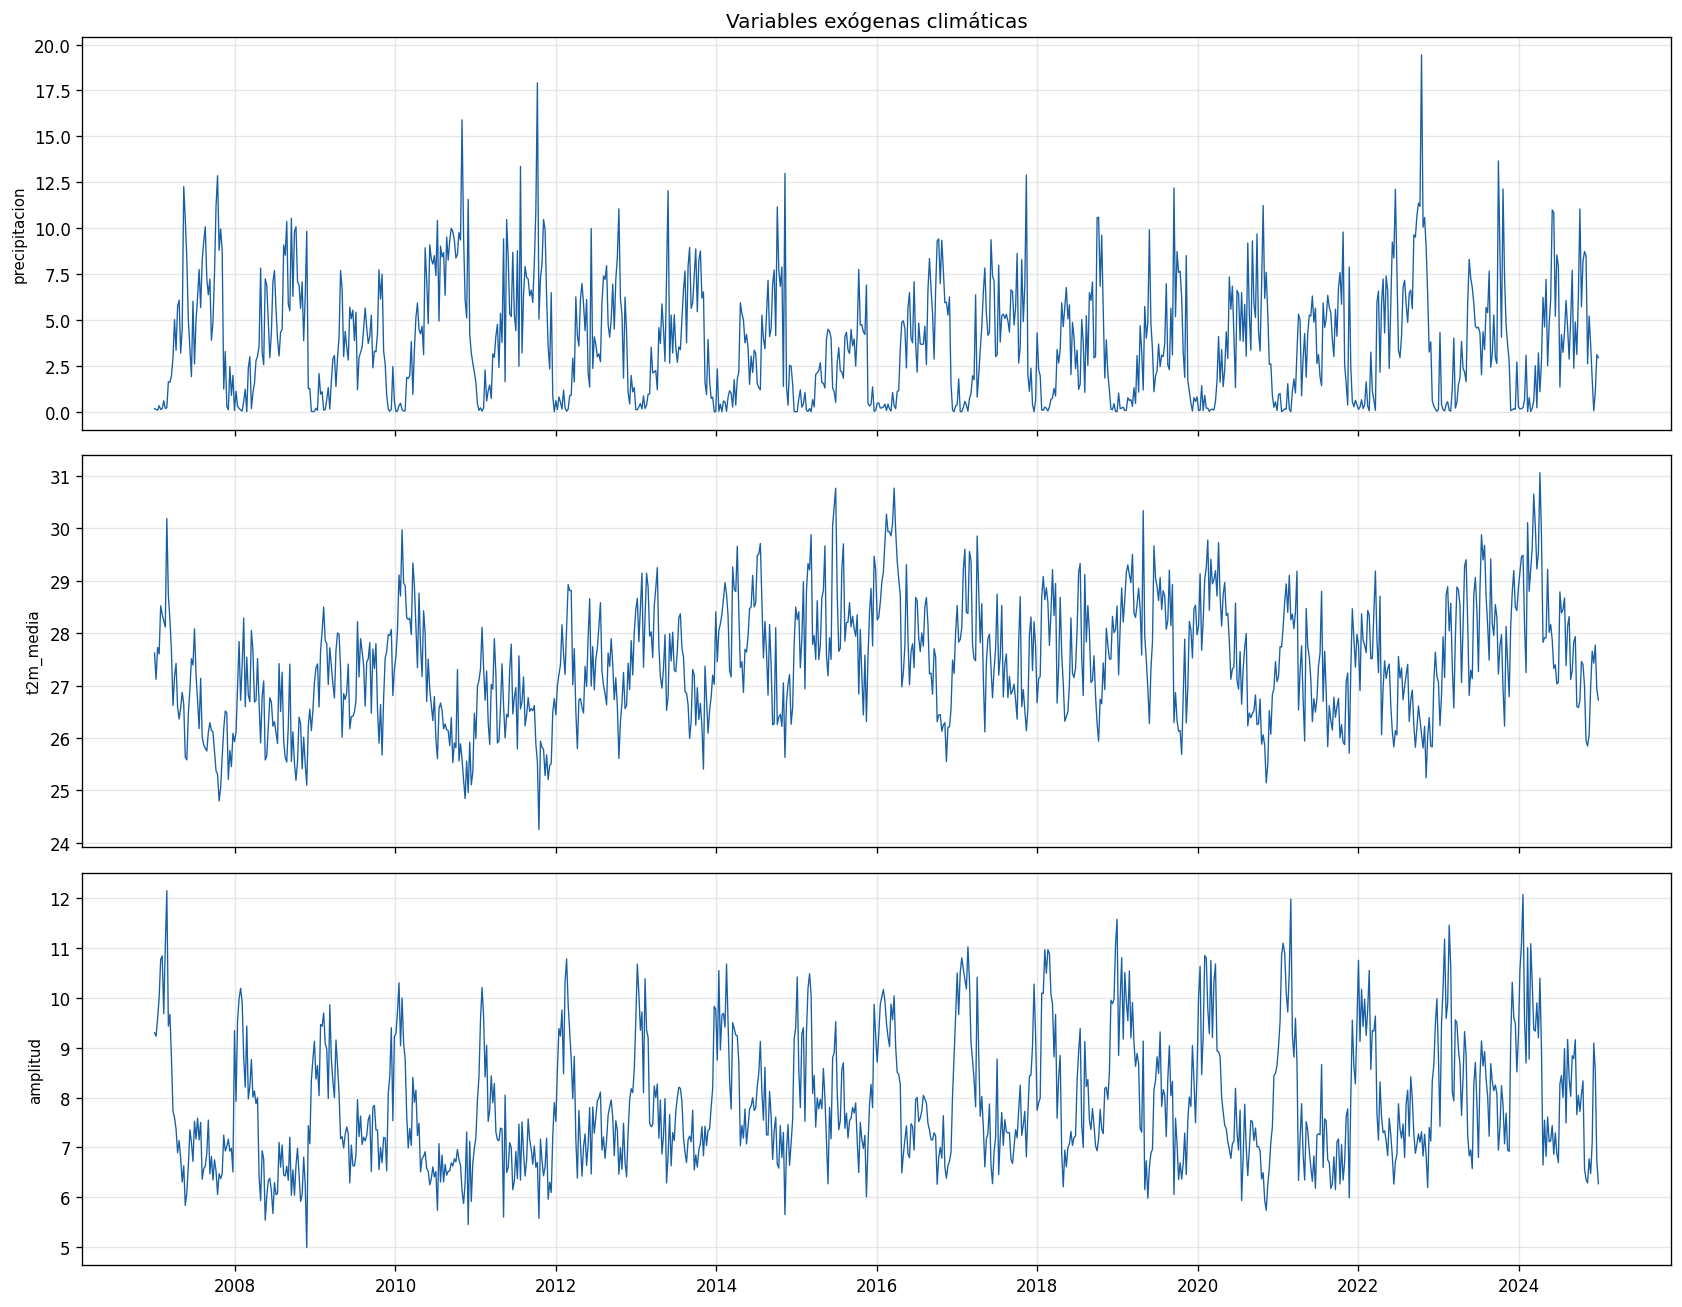

In [14]:
CLIMA_EXOG = ['precipitacion', 't2m_media', 'amplitud']

serie_exog = df_dep.set_index('fecha_semana')[CLIMA_EXOG]

filas_diag = []
for var in CLIMA_EXOG:
    s = serie_exog[var]
    cv = cv_movil(s)
    fila = evaluar(s, var)
    fila['CV movil var'] = round(float(cv.var()), 6)
    filas_diag.append(fila)

df_diag_exog = pd.DataFrame(filas_diag)[
    ['Serie', 'CV movil var', 'ADF p-valor', 'ADF', 'KPSS p-valor', 'KPSS', 'Estacionaria (ambas)']
]
print(df_diag_exog.to_string(index=False))

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for ax, var in zip(axes, CLIMA_EXOG):
    ax.plot(serie_exog.index, serie_exog[var], color='#185FA5', linewidth=0.8)
    ax.set_ylabel(var, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_title('Variables exógenas climáticas')
plt.tight_layout()
plt.savefig(OUTPUTS / 'exogenas_climaticas.png', dpi=150, bbox_inches='tight')
plt.show()

El coeficiente de variacion movil revela que precipitacion presenta una varianza notablemente menos estable que las demas variables, un patron similar al observado en la serie de casos antes de su transformacion logaritmica. Por esta razon se aplica log1p a precipitacion, evitando el problema de valores cero presentes en los registros semanales de lluvia.

Las pruebas de estacionariedad muestran un panorama distinto al de la varianza: precipitacion es la unica variable que satisface ADF y KPSS de forma conjunta sin transformar. Las 2 variables restantes (amplitud termica , t2m_media) tienen varianza estable pero ADF y KPSS no coinciden entre si (ADF concluye estacionariedad mientras KPSS la rechaza, con p-valores entre 0.01 y 0.0242), lo que es evidencia de una tendencia estocastica residual en la media. Por eso se les aplica una diferenciacion regular, que corrige la media sin necesidad de tocar la varianza, ya estable en su escala original.

In [15]:
VARS_DIFERENCIAR = ['t2m_media', 'amplitud']

serie_precip_log = np.log1p(serie_exog['precipitacion'])

series_diff = {}
filas = [evaluar(serie_precip_log, 'precipitacion_log')]
for var in VARS_DIFERENCIAR:
    serie_diff = serie_exog[var].diff()
    series_diff[f'{var}_diff'] = serie_diff
    filas.append(evaluar(serie_diff, f'{var}_diff'))

df_diag_transformadas = pd.DataFrame(filas)[
    ['Serie', 'ADF p-valor', 'ADF', 'KPSS p-valor', 'KPSS', 'Estacionaria (ambas)']
]
print(df_diag_transformadas.to_string(index=False))


            Serie  ADF p-valor          ADF  KPSS p-valor         KPSS  Estacionaria (ambas)
precipitacion_log          0.0 Estacionaria           0.1 Estacionaria                  True
   t2m_media_diff          0.0 Estacionaria           0.1 Estacionaria                  True
    amplitud_diff          0.0 Estacionaria           0.1 Estacionaria                  True


### Pipeline de datos y funcion de experimentacion

Para no repetir el tratamiento en cada experimento se definen dos funciones. La primera, preparar_datos_sarimax, construye los rezagos de las exogenas indicadas, transforma la serie de casos a escala logaritmica, y separa el bloque de entrenamiento (train mas val) del bloque de prueba segun los conjuntos de fechas de la seccion 3. La segunda, correr_sarimax, recibe la lista de exogenas y los ordenes, ajusta el modelo sobre la serie logaritmica de entrenamiento, revierte la prediccion a escala de casos con np.expm1, calcula las metricas sobre el test, grafica y registra todo en MLflow. El nombre de cada corrida se deriva de la lista de exogenas para que MLflow quede trazable sin etiquetas escritas a mano.

In [58]:
# Rezagos climaticos: justificados por el ciclo del vector + incubacion + notificacion (4-16 sem).
LAGS_CLIMA = [4, 8, 12, 16]

LAGS_TARGET = [1, 2, 4, 8]

def preparar_datos_sarimax(exog_vars, fechas_entreno, fechas_test, lags=LAGS_CLIMA):
    cols_exog = [f'{v}_lag{lag}' for v in exog_vars for lag in lags]

    base = df_dep.copy()
    for v in exog_vars:
        if v == 'precipitacion_log':
            serie_base = np.log1p(base['precipitacion'])
        elif v.endswith('_diff'):
            var_raw = v.replace('_diff', '')
            serie_base = base[var_raw].diff()
        else:
            serie_base = base[v]
        for lag in lags:
            base[f'{v}_lag{lag}'] = serie_base.shift(lag)

    base['casos_log'] = np.log1p(base['casos'])

    if cols_exog:
        base = base.dropna(subset=cols_exog)
    base = base.set_index('fecha_semana')

    entreno = base[base.index.isin(fechas_entreno)]
    test = base[base.index.isin(fechas_test)]

    y_entreno_log = entreno['casos_log']
    y_test_log = test['casos_log']
    y_test_real = test['casos']
    X_entreno = entreno[cols_exog] if cols_exog else None
    X_test = test[cols_exog] if cols_exog else None

    return y_entreno_log, y_test_log, y_test_real, X_entreno, X_test, cols_exog


def nombre_run_sarimax(exog_vars):
    if not exog_vars:
        return 'SARIMAX_SIN_EXOG'
    return 'SARIMAX_' + '_'.join(v.upper() for v in exog_vars)


def correr_sarimax(exog_vars, order, seasonal_order, fechas_entreno, fechas_test, color='#9467bd', run_name=None):
    run_name = run_name or nombre_run_sarimax(exog_vars)
    y_entreno_log, y_test_log, y_test_real, X_entreno, X_test, cols_exog = preparar_datos_sarimax(
        exog_vars, fechas_entreno, fechas_test)

    exog_entreno_arr = X_entreno.values if X_entreno is not None else None
    exog_test_arr = X_test.values if X_test is not None else None

    with mlflow.start_run(run_name=run_name):
        fit = SARIMAX(
            y_entreno_log,
            exog=exog_entreno_arr,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

        modelo_test = fit.append(y_test_log, exog=exog_test_arr, refit=False)
        pred_log = modelo_test.predict(
            start=y_test_log.index[0],
            end=y_test_log.index[-1],
            exog=exog_test_arr,
            dynamic=False,
        )

        pred = pd.Series(np.expm1(pred_log), index=y_test_real.index).clip(lower=0)

        m = compute_metrics(y_test_real, pred)
        mlflow.log_params({
            'order': str(order), 'seasonal_order': str(seasonal_order),
            'exog': ','.join(exog_vars) if exog_vars else 'ninguna',
            'exog_cols': ','.join(cols_exog) if cols_exog else 'ninguna',
            'lags_clima': ','.join(map(str, LAGS_CLIMA)), 'escala_entrenamiento': 'log1p',
            'entrenamiento': 'train+val', 'pronostico': 'rodante-1-paso',
        })
        mlflow.log_metrics(m)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(y_entreno_log.index[-52:], np.expm1(y_entreno_log).iloc[-52:],
                color='#185FA5', label=f'Entrenamiento (ultimo año de {len(y_entreno_log)} sem.)')
        ax.plot(y_test_real.index, y_test_real.values, color='black', label='Real (test)')
        ax.plot(pred.index, pred.values, color=color, linestyle='--', label=run_name)
        ax.set_title(f'{run_name} - RMSE={m["RMSE"]} | MAE={m["MAE"]} | MAPE={m["MAPE"]}% | R2={m["R2"]}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout()
        fig_path = OUTPUTS / f'{run_name}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(str(fig_path))
        plt.show()

    print_metrics(run_name, m)
    return run_name, m

### Seleccion de ordenes con auto_arima

En lugar de fijar los ordenes leyendo cada barra del correlograma (lo que en una serie con autocorrelacion fuerte lleva a sobreparametrizar, porque muchos cruces de la banda son inercia del proceso y no estructura real), se usa auto_arima para buscar los ordenes que minimizan el criterio de informacion.

Se fija D = 0 segun las pruebas de estacionariedad y se deja d = 1 confirmado por ADF y KPSS, acotando los rangos de p, q, P y Q. La busqueda se hace sobre la serie logaritmica de train mas val, sin exogenas, para aislar la seleccion de la estructura temporal; las exogenas se añaden despues en los experimentos. Como la busqueda con periodo estacional 52 es costosa, los rangos estacionales se mantienen pequeños. Una vez ejecutada, se leen los ordenes resultantes y se copian manualmente a las constantes ORDER y SEASONAL_ORDER de la celda de experimentos.

In [77]:
serie_log_entreno = np.log1p(df_trainval_dep.set_index('fecha_semana')['casos'])

modelo_auto = auto_arima(
    serie_log_entreno,
    seasonal=True, m=52,
    d=1, D=0,
    start_p=1, max_p=5,
    start_q=1, max_q=3,
    max_P=1, max_Q=1,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True,
)

print()
print(modelo_auto.summary())
print()
print('Orden regular (p, d, q):', modelo_auto.order)
print('Orden estacional (P, D, Q, s):', modelo_auto.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=17.53 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=1120.296, Time=0.13 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=978.413, Time=3.58 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=920.056, Time=3.47 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=1118.304, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=918.748, Time=0.13 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=920.095, Time=6.47 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=12.39 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=919.574, Time=0.26 sec
 ARIMA(0,1,2)(0,0,0)[52] intercept   : AIC=918.856, Time=0.41 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=976.732, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[52] intercept   : AIC=909.646, Time=0.55 sec
 ARIMA(1,1,2)(1,0,0)[52] intercept   : AIC=911.290, Time=11.32 sec
 ARIMA(1,1,2)(0,0,1)[52] intercept   : AIC=911.266, Time=12.50 sec
 ARIMA(1,1,2)(1,0,1)[52] intercept 

### Experimentos SARIMAX

Con los ordenes ya seleccionados por auto_arima (copiados manualmente en las constantes de abajo), se prueban las distintas combinaciones de variables exogenas. Todas las corridas comparten los mismos ordenes regulares y estacionales, de modo que la unica diferencia entre experimentos es el subconjunto de variables climaticas. Cada corrida entrena con train mas val, se evalua sobre el test y se registra en MLflow.


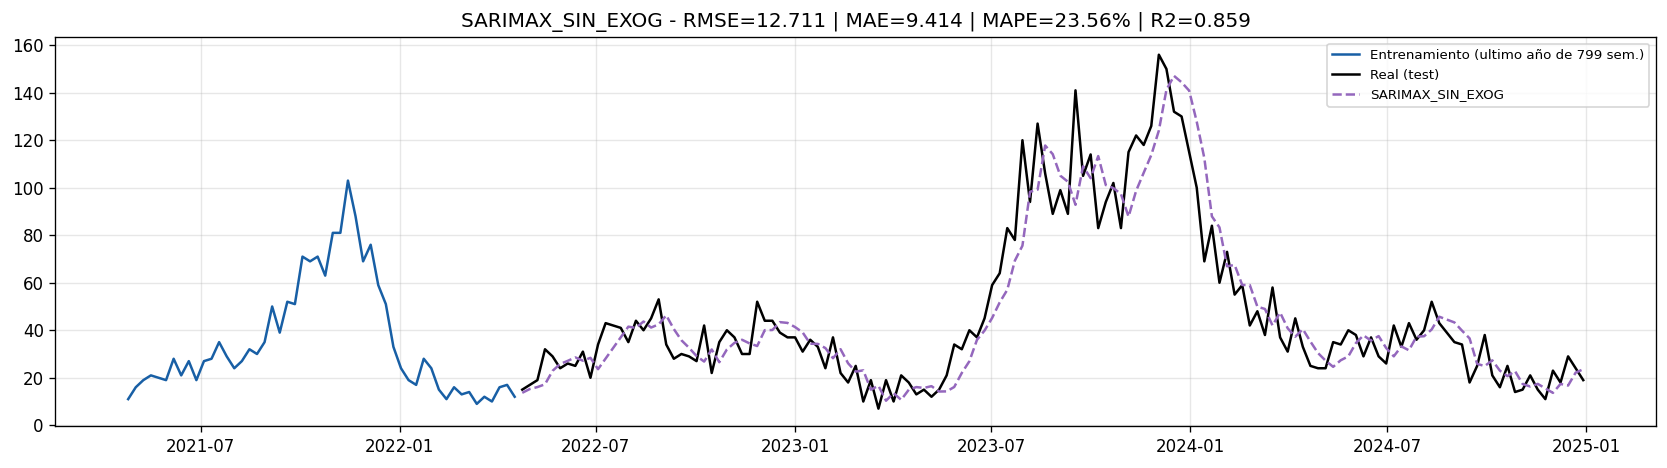

SARIMAX_SIN_EXOG                    RMSE=  12.71 | MAE=  9.41 | MAPE= 23.56% | R2=0.8590


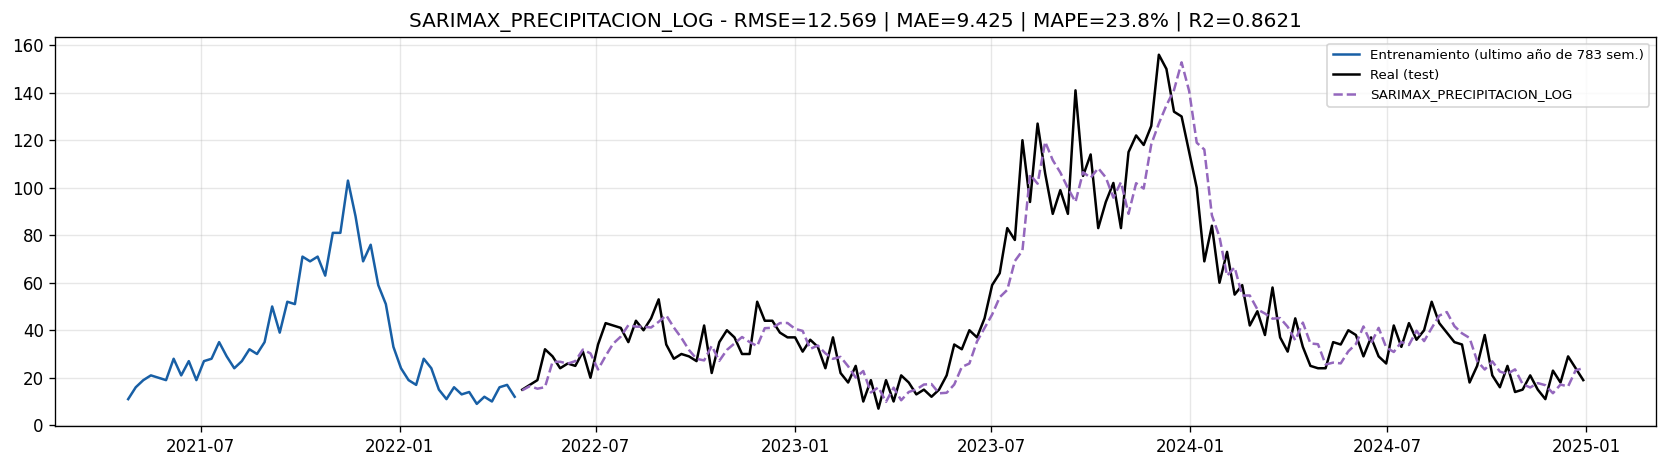

SARIMAX_PRECIPITACION_LOG           RMSE=  12.57 | MAE=  9.43 | MAPE= 23.80% | R2=0.8621


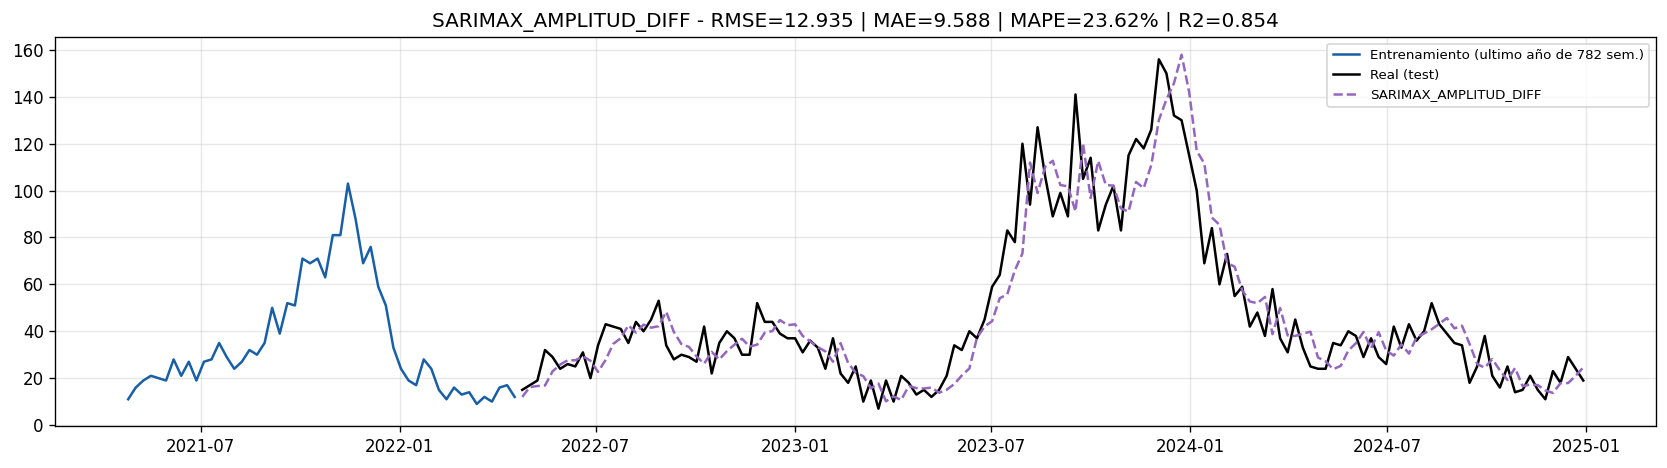

SARIMAX_AMPLITUD_DIFF               RMSE=  12.94 | MAE=  9.59 | MAPE= 23.62% | R2=0.8540


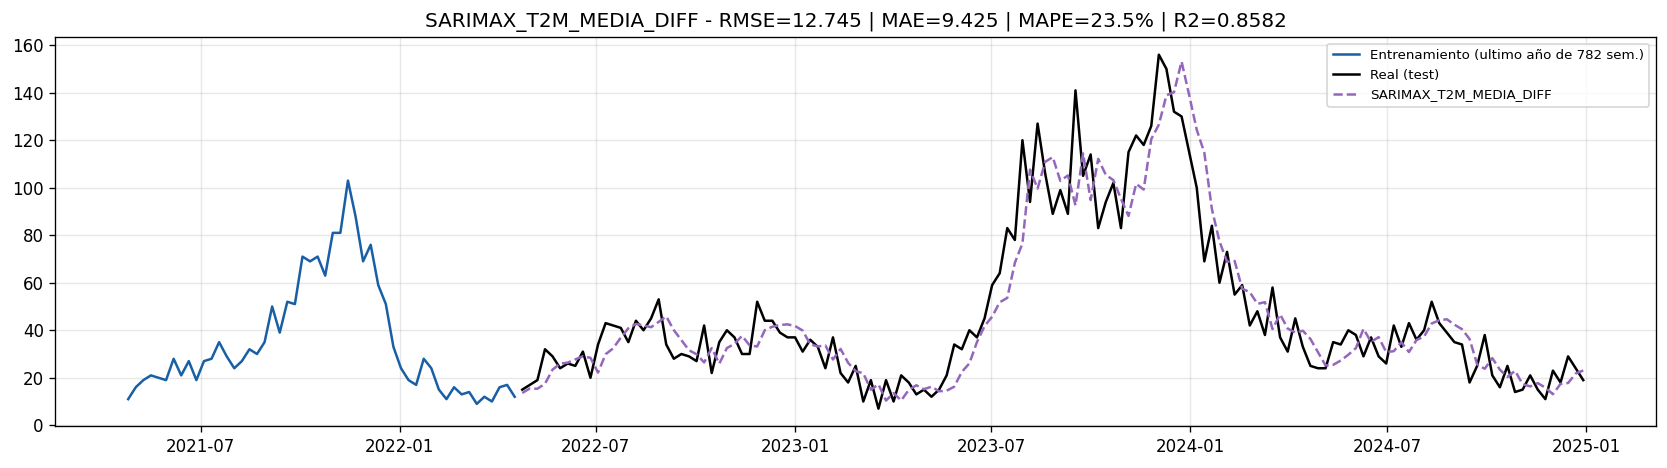

SARIMAX_T2M_MEDIA_DIFF              RMSE=  12.74 | MAE=  9.43 | MAPE= 23.50% | R2=0.8582


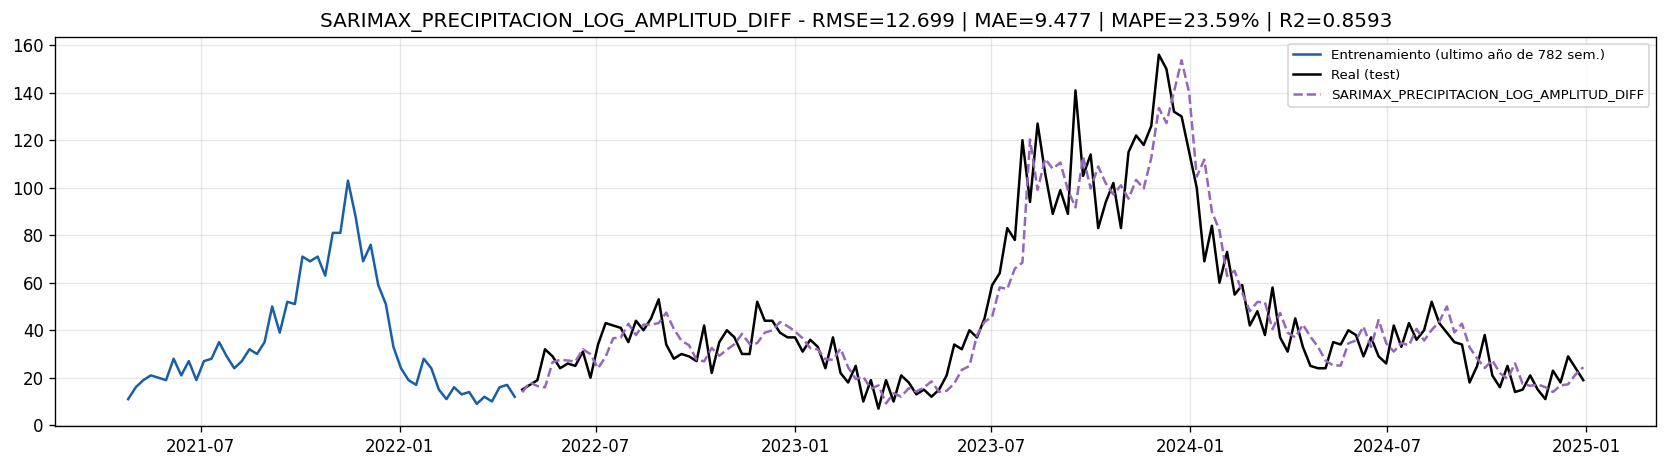

SARIMAX_PRECIPITACION_LOG_AMPLITUD_DIFF RMSE=  12.70 | MAE=  9.48 | MAPE= 23.59% | R2=0.8593


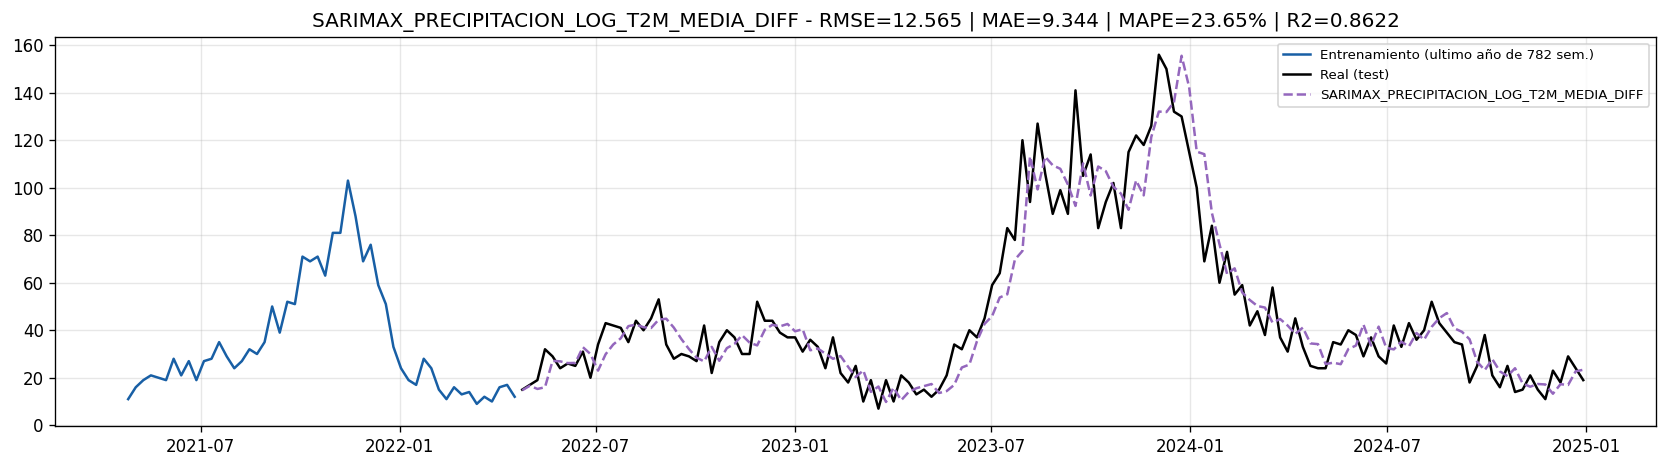

SARIMAX_PRECIPITACION_LOG_T2M_MEDIA_DIFF RMSE=  12.56 | MAE=  9.34 | MAPE= 23.65% | R2=0.8622


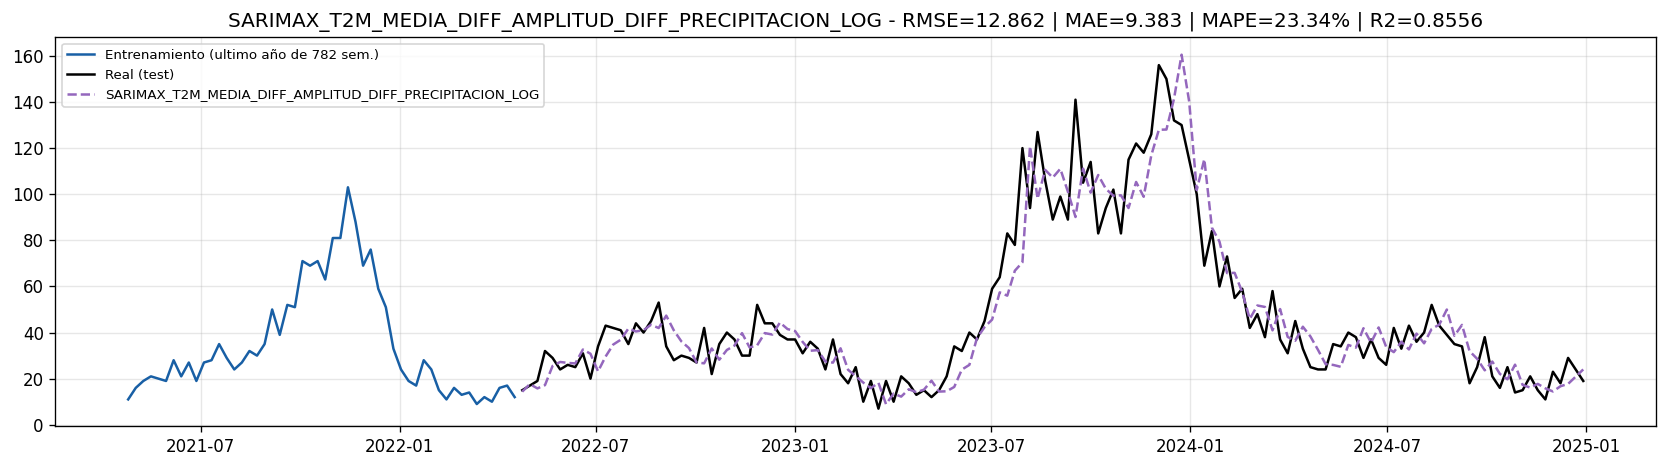

SARIMAX_T2M_MEDIA_DIFF_AMPLITUD_DIFF_PRECIPITACION_LOG RMSE=  12.86 | MAE=  9.38 | MAPE= 23.34% | R2=0.8556

                                                          RMSE    MAE   MAPE      R2
SARIMAX_PRECIPITACION_LOG_T2M_MEDIA_DIFF                12.565  9.344  23.65  0.8622
SARIMAX_PRECIPITACION_LOG                               12.569  9.425  23.80  0.8621
SARIMAX_PRECIPITACION_LOG_AMPLITUD_DIFF                 12.699  9.477  23.59  0.8593
SARIMAX_SIN_EXOG                                        12.711  9.414  23.56  0.8590
SARIMAX_T2M_MEDIA_DIFF                                  12.745  9.425  23.50  0.8582
SARIMAX_T2M_MEDIA_DIFF_AMPLITUD_DIFF_PRECIPITACION_LOG  12.862  9.383  23.34  0.8556
SARIMAX_AMPLITUD_DIFF                                   12.935  9.588  23.62  0.8540


In [59]:
ORDER = (2, 1, 2)
SEASONAL_ORDER = (0, 0, 0, 52)

combinaciones_exog = [
    [],
    ['precipitacion_log'],
    ['amplitud_diff'],
    ['t2m_media_diff'],
    ['precipitacion_log', 'amplitud_diff'],
    ['precipitacion_log', 't2m_media_diff'],
    ['t2m_media_diff', 'amplitud_diff', 'precipitacion_log'],
]

resultados_sarimax = {}
for exog_vars in combinaciones_exog:
    run_name, m = correr_sarimax(exog_vars, ORDER, SEASONAL_ORDER, FECHAS_TRAINVAL, FECHAS_TEST)
    resultados_sarimax[run_name] = m

print()
df_exp = pd.DataFrame(resultados_sarimax).T.sort_values('RMSE')
print(df_exp.to_string())

### ARIMA vs SARIMA: aporte del componente estacional

Los experimentos anteriores corrieron SARIMAX con el orden estacional en ceros, porque auto_arima no hallo estructura estacional en la ACF/PACF. Como la descomposicion STL si muestra un ciclo anual claro, aqui se verifica en aislamiento si forzar un componente estacional aporta algo. Se comparan dos modelos sin exogenas y con los mismos ordenes regulares (p, d, q): uno sin bloque estacional (ARIMA) y otro con estacionalidad anual (SARIMA, P=1, Q=1, s=52, D=0). La diferencia de RMSE sobre el test es el aporte neto del componente estacional.

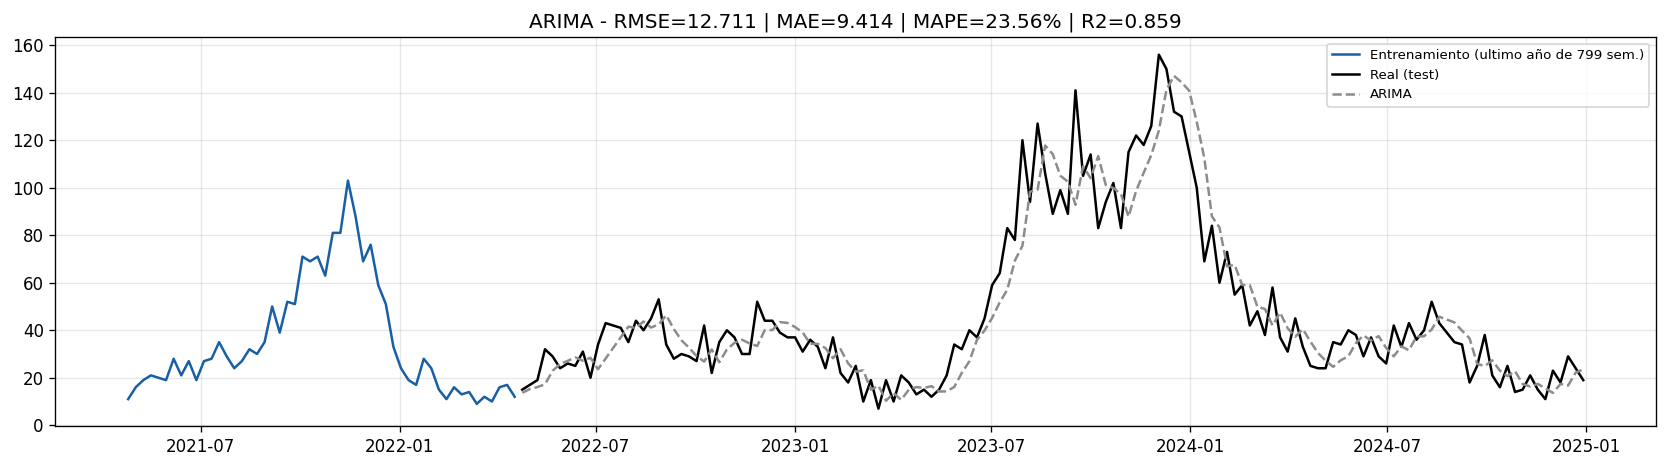

ARIMA                               RMSE=  12.71 | MAE=  9.41 | MAPE= 23.56% | R2=0.8590


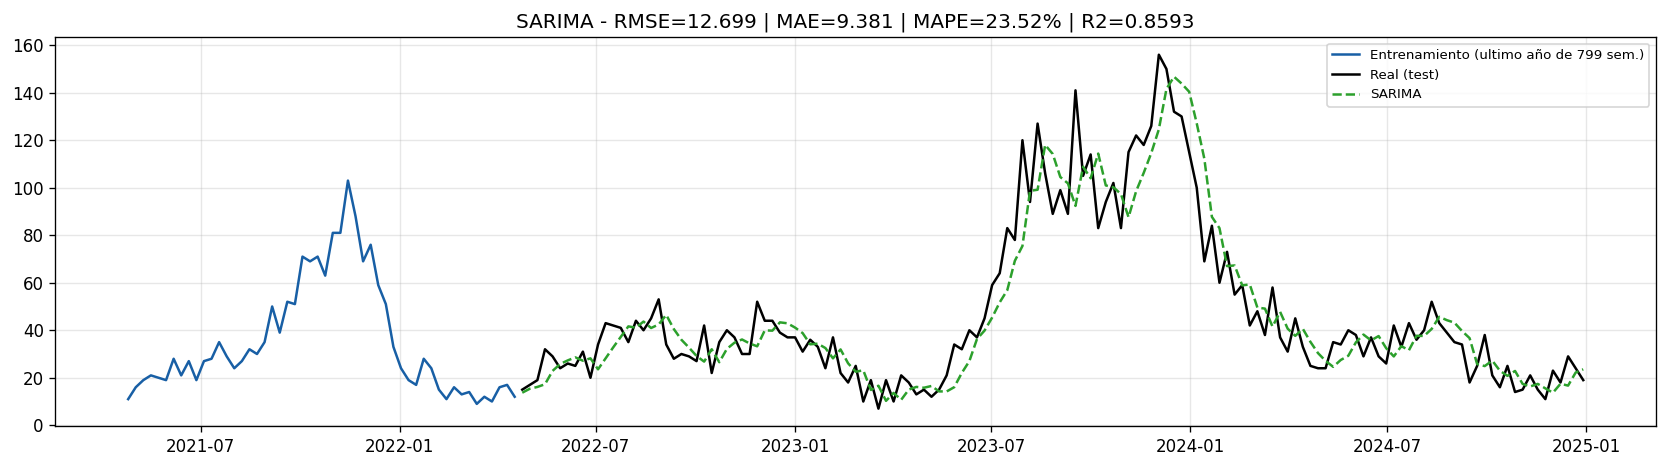

SARIMA                              RMSE=  12.70 | MAE=  9.38 | MAPE= 23.52% | R2=0.8593

          RMSE    MAE   MAPE      R2
ARIMA   12.711  9.414  23.56  0.8590
SARIMA  12.699  9.381  23.52  0.8593


In [60]:
SEASONAL_NULO = (0, 0, 0, 0)      
SEASONAL_ANUAL = (1, 0, 1, 52)   

resultados_estacional = {}
for etiqueta, sorder, color in [
    ('ARIMA', SEASONAL_NULO, '#8c8c8c'),
    ('SARIMA', SEASONAL_ANUAL, '#2CA02C'),
]:
    nombre, m = correr_sarimax([], ORDER, sorder, FECHAS_TRAINVAL, FECHAS_TEST,
                               color=color, run_name=etiqueta)
    resultados_estacional[nombre] = m

print()
print(pd.DataFrame(resultados_estacional).T.to_string())

Si la diferencia es minima, el pronostico a un paso ya captura la dinamica con la parte autorregresiva (usa el valor real de la semana previa) y el termino estacional anual resulta casi redundante en este horizonte. La estacionalidad importa más en pronosticos de horizonte largo que a un paso.

### Aporte de las variables exogenas (X)

Con el componente estacional descartado, se mide cuanto aportan las variables climaticas. La comparacion correcta es CON exogenas vs SIN exogenas manteniendo los mismos ordenes (no ARIMAX vs SARIMAX, que volveria a medir el estacional). Se toma la mejor combinacion de clima de los experimentos del paso 1 y se contrasta con el modelo sin clima; ambos ya estan calculados, asi que solo se leen sus resultados.

In [61]:
base_run = 'SARIMAX_SIN_EXOG'
mejor_con_x = df_exp.drop(base_run).index[0]   # mejor combinacion que usa clima

rmse_sin_x = resultados_sarimax[base_run]['RMSE']
rmse_con_x = resultados_sarimax[mejor_con_x]['RMSE']

print(f'Sin exogenas       : {base_run:32s} RMSE={rmse_sin_x:6.2f}')
print(f'Mejor con exogenas : {mejor_con_x:32s} RMSE={rmse_con_x:6.2f}')
delta_x = rmse_sin_x - rmse_con_x
print()
print(f'Aporte de las exogenas (clima): {delta_x:+.2f} RMSE '
      f'(> 0 = el clima mejora el pronostico a un paso)')

Sin exogenas       : SARIMAX_SIN_EXOG                 RMSE= 12.71
Mejor con exogenas : SARIMAX_PRECIPITACION_LOG_T2M_MEDIA_DIFF RMSE= 12.56

Aporte de las exogenas (clima): +0.15 RMSE (> 0 = el clima mejora el pronostico a un paso)


## 5.2 Prophet

Prophet es un modelo desarrollado por Meta para pronostico de series con estacionalidad fuerte. A diferencia de SARIMAX, descompone la serie de forma aditiva en tendencia, estacionalidad y efectos de regresores, y es mas robusto frente a datos faltantes y valores atipicos. Maneja su propia estacionalidad anual de forma interna. Se entrena en escala logaritmica de casos, igual que SARIMAX. Tambien entrena con train mas val y predice el test.

A diferencia de SARIMAX y los arboles, Prophet no tiene termino autorregresivo: predice cada semana desde la fecha, la tendencia y los regresores, sin usar el valor real de la semana previa. En esta serie ese pasado reciente es la senal dominante (casos_lag1, rho~0.91), asi que un Prophet puro queda muy por debajo. Para compararlo en igualdad de condiciones se agregan los rezagos 1, 2, 4 y 8 del target en escala log como regresores (los mismos que usan arboles y LSTM) (en escala cruda romperia, porque Prophet suma los regresores linealmente sobre y en log). Se conserva ademas una variante 'solo', sin esos rezagos, como referencia de cuanto aporta la autorregresion.

17:28:04 - cmdstanpy - INFO - Chain [1] start processing
17:28:04 - cmdstanpy - INFO - Chain [1] done processing


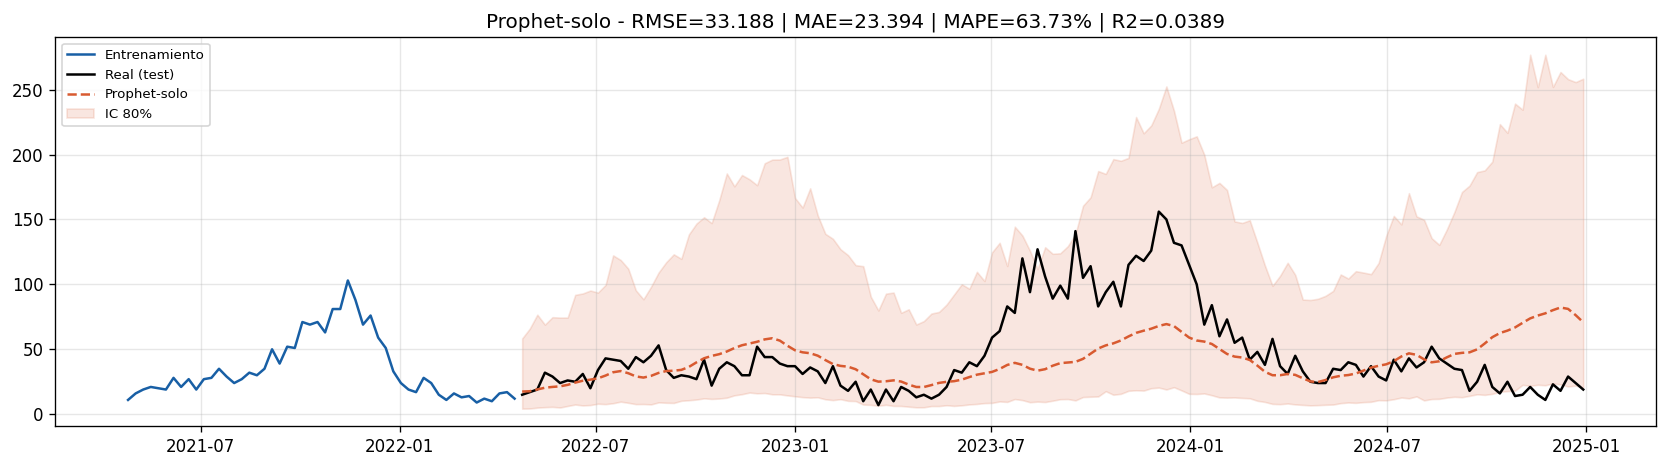

17:28:05 - cmdstanpy - INFO - Chain [1] start processing


Prophet-solo                        RMSE=  33.19 | MAE= 23.39 | MAPE= 63.73% | R2=0.0389


17:28:05 - cmdstanpy - INFO - Chain [1] done processing


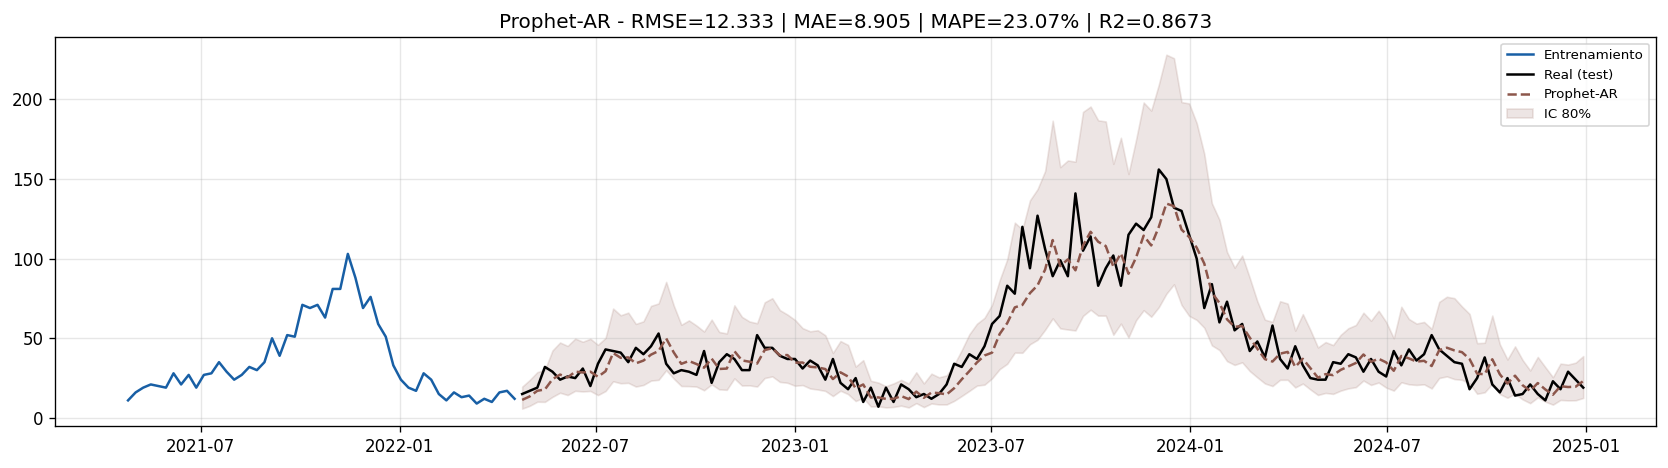

17:28:06 - cmdstanpy - INFO - Chain [1] start processing


Prophet-AR                          RMSE=  12.33 | MAE=  8.90 | MAPE= 23.07% | R2=0.8673


17:28:06 - cmdstanpy - INFO - Chain [1] done processing


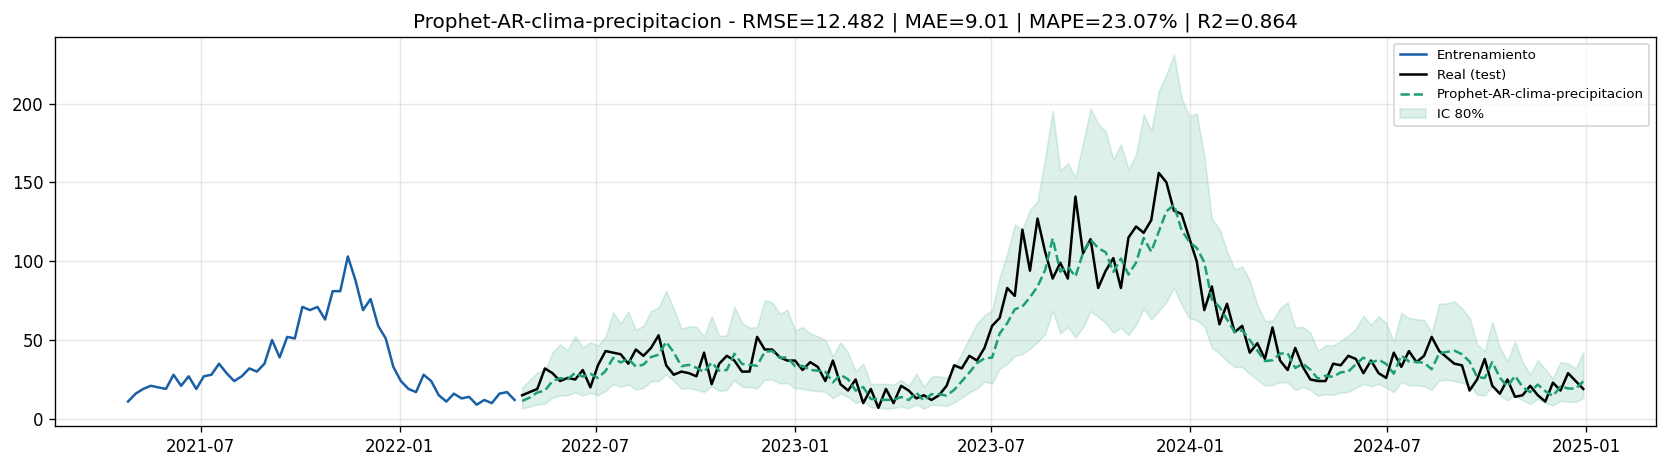

17:28:07 - cmdstanpy - INFO - Chain [1] start processing


Prophet-AR-clima-precipitacion      RMSE=  12.48 | MAE=  9.01 | MAPE= 23.07% | R2=0.8640


17:28:07 - cmdstanpy - INFO - Chain [1] done processing


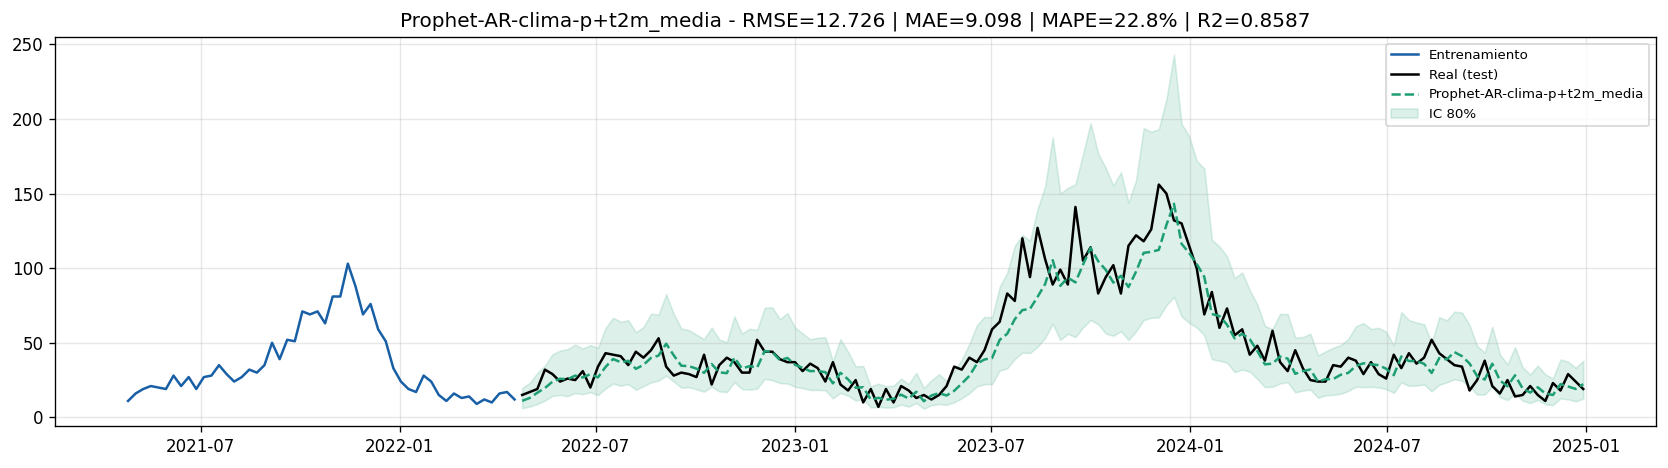

Prophet-AR-clima-p+t2m_media        RMSE=  12.73 | MAE=  9.10 | MAPE= 22.80% | R2=0.8587


17:28:08 - cmdstanpy - INFO - Chain [1] start processing
17:28:08 - cmdstanpy - INFO - Chain [1] done processing


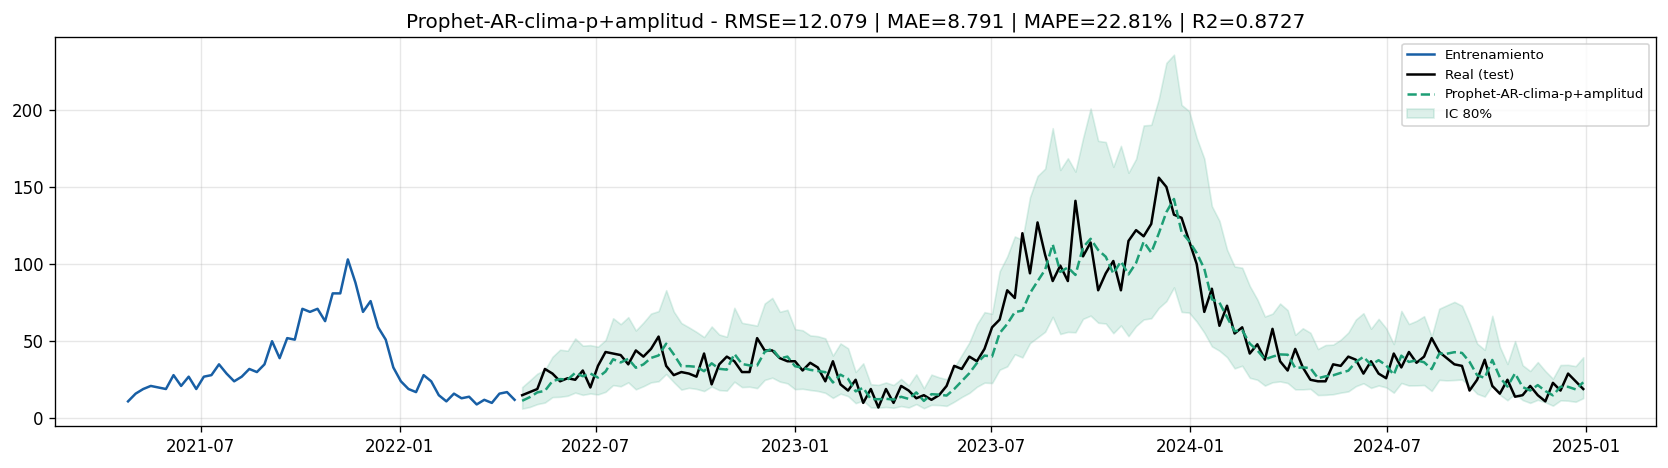

17:28:09 - cmdstanpy - INFO - Chain [1] start processing


Prophet-AR-clima-p+amplitud         RMSE=  12.08 | MAE=  8.79 | MAPE= 22.81% | R2=0.8727


17:28:09 - cmdstanpy - INFO - Chain [1] done processing


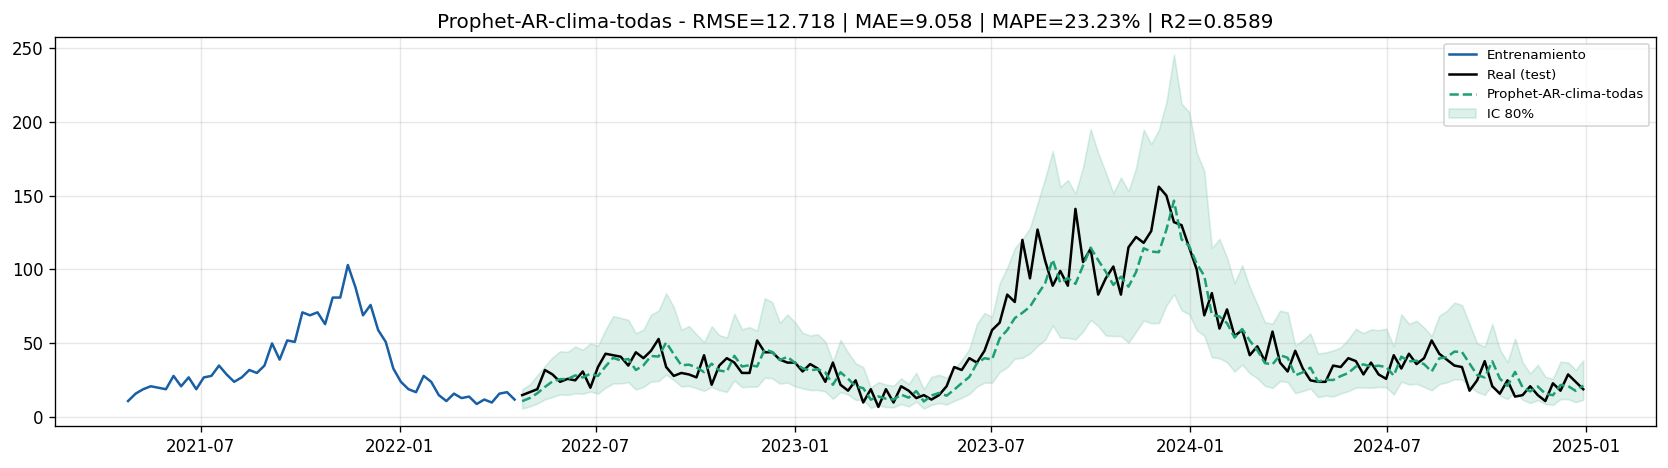

Prophet-AR-clima-todas              RMSE=  12.72 | MAE=  9.06 | MAPE= 23.23% | R2=0.8589

                                  RMSE     MAE   MAPE      R2
Prophet-AR-clima-p+amplitud     12.079   8.791  22.81  0.8727
Prophet-AR                      12.333   8.905  23.07  0.8673
Prophet-AR-clima-precipitacion  12.482   9.010  23.07  0.8640
Prophet-AR-clima-todas          12.718   9.058  23.23  0.8589
Prophet-AR-clima-p+t2m_media    12.726   9.098  22.80  0.8587
Prophet-solo                    33.188  23.394  63.73  0.0389


In [62]:
TODAS_EXOG = ['precipitacion_log', 't2m_media', 'amplitud']

base_p = df_dep.copy()
base_p['precipitacion_log'] = np.log1p(base_p['precipitacion'])

# Clima: lags largos (mecanismo biologico)
for v in TODAS_EXOG:
    for lag in LAGS_CLIMA:
        base_p[f'{v}_lag{lag}'] = base_p[v].shift(lag)

# Target: lags cortos (inercia autorregresiva)
base_p['casos_log'] = np.log1p(base_p['casos'])
COLS_AR = []
for lag in LAGS_TARGET:
    col = f'casos_lag{lag}_log'
    base_p[col] = base_p['casos_log'].shift(lag)
    COLS_AR.append(col)

cols_todas = [f'{v}_lag{lag}' for v in TODAS_EXOG for lag in LAGS_CLIMA]
base_p = base_p.dropna(subset=cols_todas + COLS_AR)

entreno_p = base_p[base_p['fecha_semana'].isin(FECHAS_TRAINVAL)]
test_p = base_p[base_p['fecha_semana'].isin(FECHAS_TEST)]


def correr_prophet(exog_vars, run_name, color, usar_ar=True):
    cols = [f'{v}_lag{lag}' for v in exog_vars for lag in LAGS_CLIMA]   # <- LAGS_CLIMA
    if usar_ar:
        cols = COLS_AR + cols

    df_entreno = entreno_p[['fecha_semana', 'casos_log'] + cols].rename(
        columns={'fecha_semana': 'ds', 'casos_log': 'y'})
    df_test = test_p[['fecha_semana', 'casos'] + cols].rename(
        columns={'fecha_semana': 'ds', 'casos': 'y'})

    with mlflow.start_run(run_name=run_name):
        m_obj = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in cols:
            m_obj.add_regressor(col)
        m_obj.fit(df_entreno)

        forecast = m_obj.predict(df_test)
        pred = np.expm1(forecast['yhat']).clip(lower=0).values
        pred_lower = np.expm1(forecast['yhat_lower']).clip(lower=0)
        pred_upper = np.expm1(forecast['yhat_upper']).clip(lower=0)

        m = compute_metrics(df_test['y'], pred)
        mlflow.log_params({
            'yearly_seasonality': True, 'autorregresivo': usar_ar,
            'regressors': ','.join(exog_vars) if exog_vars else 'ninguna',
            'lags_clima': ','.join(map(str, LAGS_CLIMA)),
            'lags_target': ','.join(map(str, LAGS_TARGET)),
            'escala_entrenamiento': 'log1p', 'entrenamiento': 'train+val',
            'escala': 'departamental',
        })
        mlflow.log_metrics(m)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(df_entreno['ds'].iloc[-52:], np.expm1(df_entreno['y']).iloc[-52:],
                color='#185FA5', label='Entrenamiento')
        ax.plot(df_test['ds'], df_test['y'], color='black', label='Real (test)')
        ax.plot(forecast['ds'], pred, color=color, linestyle='--', label=run_name)
        ax.fill_between(forecast['ds'], pred_lower, pred_upper, alpha=0.15, color=color, label='IC 80%')
        ax.set_title(f'{run_name} - RMSE={m["RMSE"]} | MAE={m["MAE"]} | MAPE={m["MAPE"]}% | R2={m["R2"]}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout()
        fig_path = OUTPUTS / f'{run_name}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(str(fig_path))
        plt.show()

    print_metrics(run_name, m)
    return m


resultados_prophet = {}

# Sin AR: solo tendencia + estacionalidad anual (referencia del peso del AR).
resultados_prophet['Prophet-solo'] = correr_prophet([], run_name='Prophet-solo', color='#D85A30', usar_ar=False)
# Con los rezagos autorregresivos, en igualdad con los demas modelos.
resultados_prophet['Prophet-AR'] = correr_prophet([], run_name='Prophet-AR', color='#8c564b', usar_ar=True)

# AR + clima, para ver si el clima aporta algo sobre los rezagos del target.
combinaciones_prophet = {
    'Prophet-AR-clima-precipitacion': ['precipitacion_log'],
    'Prophet-AR-clima-p+t2m_media': ['precipitacion_log', 't2m_media'],
    'Prophet-AR-clima-p+amplitud': ['precipitacion_log', 'amplitud'],
    'Prophet-AR-clima-todas': ['precipitacion_log', 't2m_media', 'amplitud'],
}
for nombre, exog_vars in combinaciones_prophet.items():
    resultados_prophet[nombre] = correr_prophet(exog_vars, run_name=nombre, color='#1D9E75', usar_ar=True)

print()
df_prophet = pd.DataFrame(resultados_prophet).T.sort_values('RMSE')
print(df_prophet.to_string())

# 6 Gradient Boosting

A diferencia de los modelos estadisticos que reciben solo la serie de casos, estos usan features construidas a partir de la serie (lags, medias moviles, codificacion de calendario). El gradient boosting construye muchos arboles de decision secuencialmente, donde cada arbol corrige los errores del anterior, lo que captura bien las relaciones no lineales entre el clima y los casos. La ingenieria de caracteristicas es especifica de esta familia: los modelos estadisticos no la usan y las redes neuronales arman sus propias secuencias, por lo que se construye aqui y no antes.

Los hiperparametros se eligen con validacion cruzada temporal (TimeSeriesSplit dentro de GridSearchCV) sobre el bloque train mas val, que respeta el orden cronologico y nunca usa semanas futuras para validar semanas pasadas. Una vez fijados, el modelo se reentrena con todo train mas val y se evalua una sola vez sobre el test. No se usa early stopping: con la busqueda en malla, el numero de arboles se trata como un hiperparametro mas y la regularizacion controla el sobreajuste.

## 6.1 Ingenieria de caracteristicas (lag features, rolling, clima)

Los modelos de arboles no entienden el tiempo por si solos: necesitan que la informacion temporal se exprese como columnas. Se generan lags climaticos (el rezago de 2 semanas refleja el periodo de incubacion extrinseco del virus en el mosquito)

La creacion de lags antes de la division no produce fuga porque cada lag usa unicamente valores anteriores de la propia serie. Tras construir las features se asigna cada fila a train mas val o a test segun los conjuntos de fechas de la seccion 3, de modo que la particion coincida con la del resto de modelos.

In [63]:
CLIMA_VARS = ['precipitacion', 'amplitud', 't2m_media']
LAGS_CLIMA = [4, 8, 12, 16]
LAGS_TARGET = [1, 2, 4, 8]


def build_features(serie_dep: pd.DataFrame) -> pd.DataFrame:
    out = serie_dep.copy().sort_values('fecha_semana').reset_index(drop=True)
    out['semana_epi'] = out['fecha_semana'].dt.isocalendar().week.astype(int)

    for var in CLIMA_VARS:
        for lag in LAGS_CLIMA:
            out[f'{var}_lag{lag}'] = out[var].shift(lag)

    for lag in LAGS_TARGET:
        out[f'casos_lag{lag}'] = out['casos'].shift(lag)

    return out.dropna().reset_index(drop=True)


df_feat = build_features(df_dep)
print(f'Serie departamental con features: {df_feat.shape}')
print(f'Features nuevas: {len(df_feat.columns) - len(df_dep.columns)}')
df_feat.head(3)


Serie departamental con features: (924, 26)
Features nuevas: 16


,fecha_semana,anio_epi,semana_epi,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min,amplitud,...,amplitud_lag12,amplitud_lag16,t2m_media_lag4,t2m_media_lag8,t2m_media_lag12,t2m_media_lag16,casos_lag1,casos_lag2,casos_lag4,casos_lag8
0,2007-04-22,2007,16,6,86.747337,6.074948,30.351538,26.361139,23.212488,7.139050,...,10.765955,9.297224,26.619890,30.189234,28.522766,27.621094,6.0,1.0,5.0,8.0
1,2007-04-29,2007,17,7,86.689590,3.191292,30.718918,26.573679,23.931299,6.787619,...,10.837147,9.228098,27.167219,28.719662,28.359701,27.119850,6.0,6.0,2.0,7.0
2,2007-05-06,2007,18,4,87.999924,4.505979,30.639629,26.868044,24.330109,6.309521,...,9.680241,9.581429,27.423609,28.271009,28.239107,27.727676,7.0,6.0,1.0,3.0


In [64]:
# Asignacion de las features tabulares a train+val y test, con las fechas de la seccion 3.
df_trainval_feat = df_feat[df_feat['fecha_semana'].isin(FECHAS_TRAINVAL)].copy()
df_test_feat = df_feat[df_feat['fecha_semana'].isin(FECHAS_TEST)].copy()

# Features para los modelos de arboles: se excluyen columnas no predictoras
FEATURE_COLS = [
    c for c in df_feat.columns
    if c not in ['fecha_semana', 'municipio', 'anio_epi', 'casos', 'semana_epi',
                 'humedad', 't2m_max', 't2m_min', 'precipitacion', 'amplitud', 't2m_media']
]

X_trainval = df_trainval_feat[FEATURE_COLS]
y_trainval = df_trainval_feat['casos']
X_test = df_test_feat[FEATURE_COLS]
y_test = df_test_feat['casos']

print(f'Train+Val features: {X_trainval.shape} | Test features: {X_test.shape}')
print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Train+Val features: (783, 16) | Test features: (141, 16)
Total features: 16
['precipitacion_lag4', 'precipitacion_lag8', 'precipitacion_lag12', 'precipitacion_lag16', 'amplitud_lag4', 'amplitud_lag8', 'amplitud_lag12', 'amplitud_lag16', 't2m_media_lag4', 't2m_media_lag8', 't2m_media_lag12', 't2m_media_lag16', 'casos_lag1', 'casos_lag2', 'casos_lag4', 'casos_lag8']


### Validacion cruzada temporal para hiperparametros

Se define una funcion reutilizable que ejecuta GridSearchCV con TimeSeriesSplit sobre train mas val. TimeSeriesSplit genera cortes crecientes en el tiempo (cada fold entrena con el pasado y valida con el bloque siguiente), por lo que nunca usa el futuro para validar. La metrica de seleccion es el RMSE negativo. La funcion devuelve el mejor estimador ya reentrenado sobre todo train mas val (refit automatico de GridSearchCV) y registra los mejores hiperparametros y el RMSE de validacion cruzada en MLflow.

In [65]:
N_SPLITS_CV = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False,
)


def buscar_hiperparametros(estimador, param_grid, X, y):
    grid = GridSearchCV(
        estimator=estimador,
        param_grid=param_grid,
        scoring=rmse_scorer,
        cv=tscv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X, y)
    rmse_cv = -grid.best_score_
    return grid.best_estimator_, grid.best_params_, rmse_cv

## 6.2 XGBoost

XGBoost es una implementacion de gradient boosting reconocida por su desempeño en datos tabulares. Construye los arboles optimizando una funcion de perdida con regularizacion, lo que ayuda a controlar el sobreajuste. Sus hiperparametros se eligen con la validacion cruzada temporal definida arriba; el mejor modelo, ya reentrenado sobre train mas val, se evalua sobre el test.

In [25]:
XGB_PARAM_GRID = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.04, 0.05],
    'n_estimators': [200, 300, 400],
    'min_child_weight': [3, 5, 7], 
}
xgb_base = XGBRegressor(
    random_state=42, n_jobs=-1,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=3, 
)

_, best_params_xgb, rmse_cv_xgb = buscar_hiperparametros(
    xgb_base, XGB_PARAM_GRID, X_trainval, y_trainval)
print(f'Mejores hiperparametros XGBoost: {best_params_xgb}')
print(f'RMSE validacion cruzada: {rmse_cv_xgb:.3f}')

Mejores hiperparametros XGBoost: {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 300}
RMSE validacion cruzada: 14.138


Hiperparametros usados: {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 300}


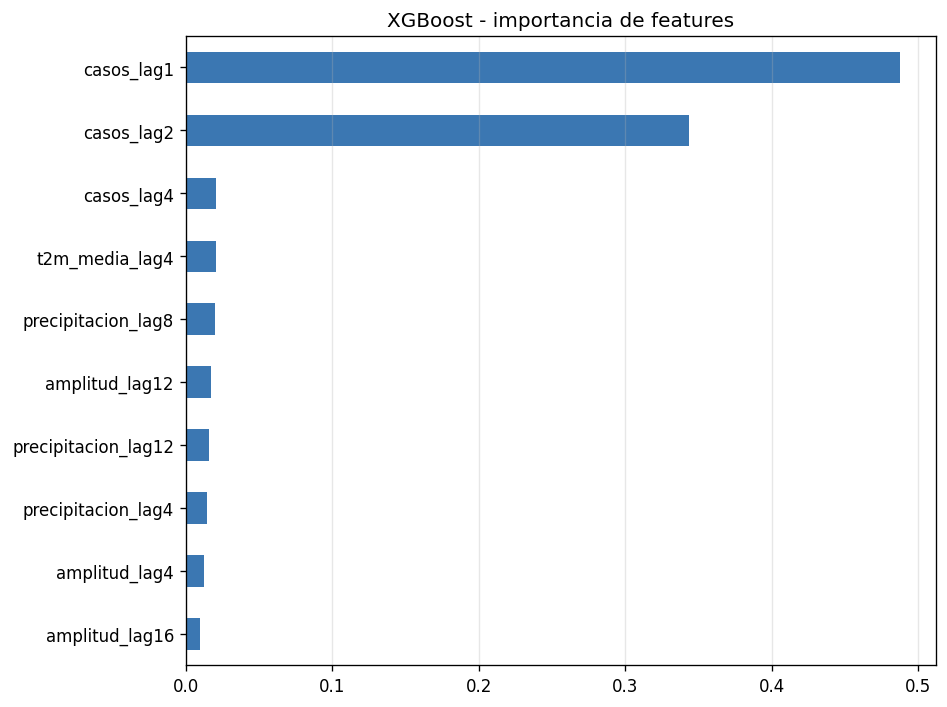

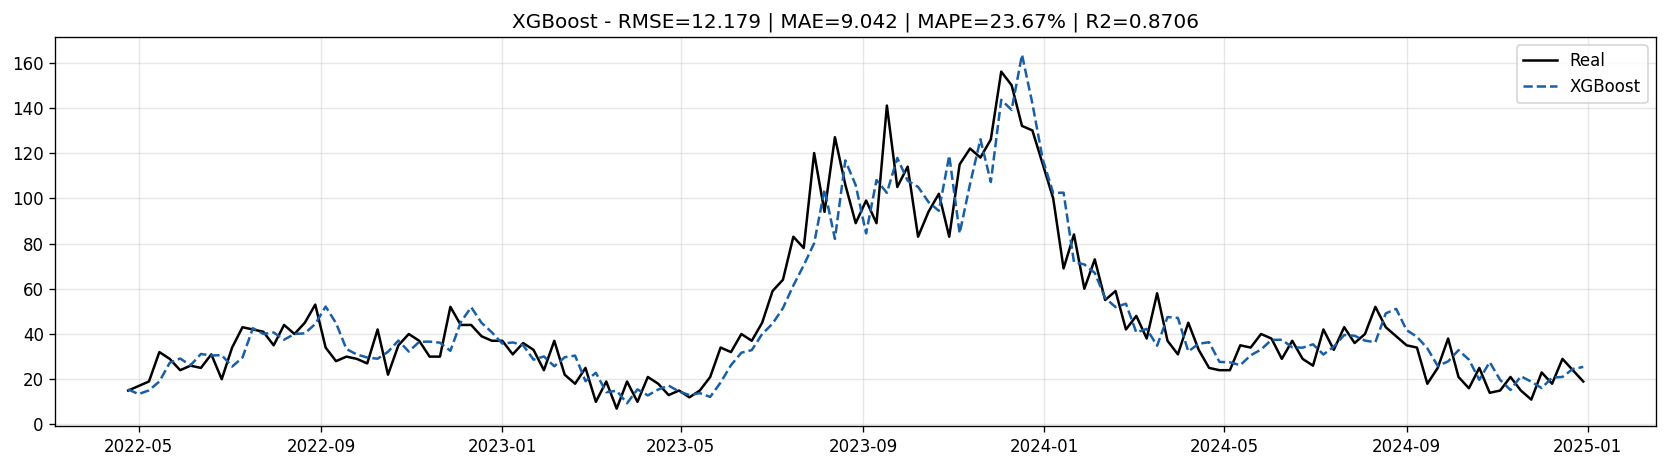

XGBoost-departamental               RMSE=  12.18 | MAE=  9.04 | MAPE= 23.67% | R2=0.8706


In [66]:
PARAMS_XGB = dict(best_params_xgb)

with mlflow.start_run(run_name='XGBoost-departamental'):
    xgb = XGBRegressor(random_state=42, n_jobs=-1, importance_type='gain' ,**PARAMS_XGB)
    xgb.fit(X_trainval, y_trainval)

    pred_xgb = xgb.predict(X_test).clip(min=0)
    m_xgb = compute_metrics(y_test, pred_xgb)

    mlflow.log_params({**PARAMS_XGB, 'escala': 'departamental',
                       'seleccion': 'GridSearchCV+TimeSeriesSplit', 'cv_splits': N_SPLITS_CV})
    mlflow.log_metric('rmse_cv', round(rmse_cv_xgb, 3))
    mlflow.log_metrics(m_xgb)
    mlflow.xgboost.log_model(xgb, name='model')
    print(f'Hiperparametros usados: {PARAMS_XGB}')

    feat_imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).nlargest(10)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp_xgb.sort_values().plot(kind='barh', ax=ax, color='#185FA5', alpha=0.85)
    ax.set_title('XGBoost - importancia de features')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    imp_path = OUTPUTS / 'xgb_feature_importance.png'
    plt.savefig(imp_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(imp_path))
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df_test_feat['fecha_semana'], y_test.values, color='black', label='Real')
    ax.plot(df_test_feat['fecha_semana'], pred_xgb, color='#185FA5', linestyle='--', label='XGBoost')
    ax.set_title(f'XGBoost - RMSE={m_xgb["RMSE"]} | MAE={m_xgb["MAE"]} | MAPE={m_xgb["MAPE"]}% | R2={m_xgb["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'xgb_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('XGBoost-departamental', m_xgb)

## 6.3 LightGBM

LightGBM es otra implementacion de gradient boosting, optimizada para ser mas rapida y eficiente en memoria que XGBoost, con desempeño comparable. Crece los arboles por hojas (leaf-wise) en lugar de por niveles. Sigue el mismo procedimiento de seleccion por validacion cruzada temporal. Se usa ademas como modelo base para el analisis de interpretabilidad SHAP de la seccion 9.

In [27]:
LGBM_PARAM_GRID = {
    'num_leaves': [7, 15, 31],         
    'learning_rate': [0.01, 0.02, 0.03],
    'n_estimators': [200, 300, 400],
    'min_child_samples': [10, 20, 30], 
}
lgbm_base = LGBMRegressor(
    random_state=42, n_jobs=-1, verbose=-1,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=3, 
)

_, best_params_lgbm, rmse_cv_lgbm = buscar_hiperparametros(
    lgbm_base, LGBM_PARAM_GRID, X_trainval, y_trainval)
print(f'Mejores hiperparametros LightGBM: {best_params_lgbm}')
print(f'RMSE validacion cruzada: {rmse_cv_lgbm:.3f}')

Mejores hiperparametros LightGBM: {'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 7}
RMSE validacion cruzada: 14.477


2026/07/09 17:29:20 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Hiperparametros usados: {'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 7}


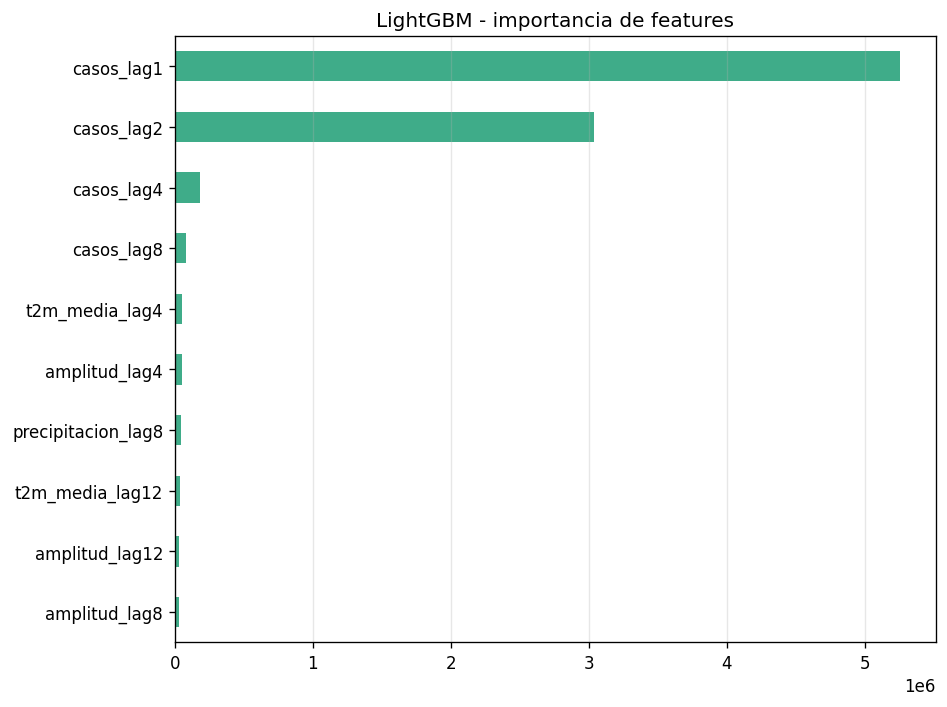

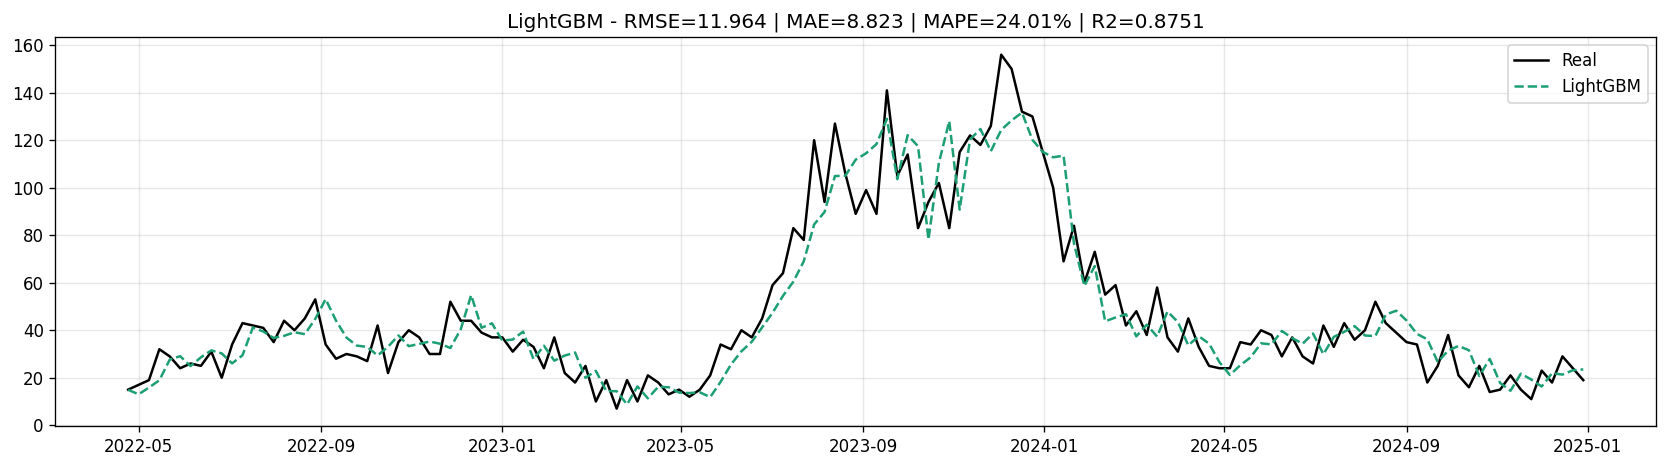

LightGBM-departamental              RMSE=  11.96 | MAE=  8.82 | MAPE= 24.01% | R2=0.8751


In [67]:
PARAMS_LGBM = dict(best_params_lgbm)

with mlflow.start_run(run_name='LightGBM-departamental'):
    lgbm = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, importance_type='gain',**PARAMS_LGBM)
    lgbm.fit(X_trainval, y_trainval)

    pred_lgbm = lgbm.predict(X_test).clip(min=0)
    m_lgbm = compute_metrics(y_test, pred_lgbm)

    mlflow.log_params({**PARAMS_LGBM, 'escala': 'departamental',
                       'seleccion': 'GridSearchCV+TimeSeriesSplit', 'cv_splits': N_SPLITS_CV})
    mlflow.log_metric('rmse_cv', round(rmse_cv_lgbm, 3))
    mlflow.log_metrics(m_lgbm)
    mlflow.lightgbm.log_model(lgbm, name='model')
    print(f'Hiperparametros usados: {PARAMS_LGBM}')

    feat_imp_lgbm = pd.Series(lgbm.feature_importances_, index=FEATURE_COLS).nlargest(10)
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp_lgbm.sort_values().plot(kind='barh', ax=ax, color='#1D9E75', alpha=0.85)
    ax.set_title('LightGBM - importancia de features')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    imp_path = OUTPUTS / 'lgbm_feature_importance.png'
    plt.savefig(imp_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(imp_path))
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df_test_feat['fecha_semana'], y_test.values, color='black', label='Real')
    ax.plot(df_test_feat['fecha_semana'], pred_lgbm, color='#1D9E75', linestyle='--', label='LightGBM')
    ax.set_title(f'LightGBM - RMSE={m_lgbm["RMSE"]} | MAE={m_lgbm["MAE"]} | MAPE={m_lgbm["MAPE"]}% | R2={m_lgbm["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'lgbm_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('LightGBM-departamental', m_lgbm)

# 7 Deep Learning

Esta seccion agrupa los modelos de redes neuronales. A diferencia de los modelos de arboles, que requieren features construidas a mano, las redes aprenden la estructura temporal directamente de ventanas de semanas consecutivas. Ambos modelos de esta seccion (LSTM y N-BEATS) reservan un bloque de validacion interno, recortado del final de train mas val mediante FECHAS_VAL, que se usa solo para early stopping. El test es el mismo 15 por ciento final que el de los demas modelos. Ademas, cada modelo incluye una busqueda de hiperparametros en una celda aparte del entrenamiento (grilla reducida evaluada sobre la validacion interna), para variar la configuracion sin repetir todo el ajuste.

## 7.1 LSTM - preparacion de secuencias

Las redes LSTM (Long Short-Term Memory) son un tipo de red neuronal recurrente diseñada para aprender dependencias temporales largas. La red recibe una ventana de semanas consecutivas y aprende sola que informacion del pasado es relevante. La ventana de entrada es de 12 semanas.

El orden de preprocesamiento es importante y sigue la secuencia correcta: primero se transforma la serie de casos con log1p para estabilizar la varianza, luego se ajusta el MinMaxScaler solo con los datos de entrenamiento (hasta el inicio de la validacion interna) para no filtrar informacion futura, y por ultimo se construyen las secuencias deslizantes. En la inversion se aplica primero el inverse_transform del scaler y despues expm1, revirtiendo las dos transformaciones en el orden inverso al que se aplicaron. El corte de validacion interno se obtiene de FECHAS_VAL y solo se usa para el early stopping.

In [47]:
LSTM_FEATURES = ['casos', 't2m_media', 'precipitacion', 'amplitud']
WINDOW = 12

# Indexado por fecha y ordenado cronologicamente sobre todo el periodo.
df_lstm_raw = df_dep.set_index('fecha_semana')[LSTM_FEATURES].copy()

# log1p sobre casos ANTES de escalar (la varianza de casos crece con el nivel)
df_lstm_log = df_lstm_raw.copy()
df_lstm_log['casos'] = np.log1p(df_lstm_log['casos'])

# Limites de posicion alineados a las fechas de la seccion 3.
# train interno = train (70%), val interno = val (15%), test = test (15%).
fechas_orden = df_lstm_log.index
pos_val = fechas_orden.isin(FECHAS_TRAIN).sum()            # fin de train, inicio de val
pos_test = pos_val + fechas_orden.isin(FECHAS_VAL).sum()   # fin de val, inicio de test

# Scaler ajustado SOLO con el train interno (en escala log para casos).
scaler = MinMaxScaler()
scaler.fit(df_lstm_log.iloc[:pos_val][LSTM_FEATURES])
scaled = scaler.transform(df_lstm_log[LSTM_FEATURES])
df_scaled = pd.DataFrame(scaled, index=df_lstm_log.index, columns=LSTM_FEATURES)


def make_sequences(df_s, window=WINDOW):
    arr = df_s[LSTM_FEATURES].values
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i - window:i])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)


X_all, y_all = make_sequences(df_scaled)

X_tr = X_all[:pos_val - WINDOW]
y_tr = y_all[:pos_val - WINDOW]
X_va = X_all[pos_val - WINDOW:pos_test - WINDOW]
y_va = y_all[pos_val - WINDOW:pos_test - WINDOW]
X_te = X_all[pos_test - WINDOW:]
y_te = y_all[pos_test - WINDOW:]

print(f'Train: {X_tr.shape} | Val (early stopping): {X_va.shape} | Test: {X_te.shape}')
print('GPU TF:', tf.config.list_physical_devices('GPU') or 'no visible (CPU)')


def inverse_casos(arr_scaled):
    dummy = np.zeros((len(arr_scaled), len(LSTM_FEATURES)))
    dummy[:, 0] = arr_scaled
    casos_log = scaler.inverse_transform(dummy)[:, 0]
    return np.expm1(casos_log).clip(min=0)


def create_model(input_shape, lstm_units=(64, 32), lstm_activation='tanh',
                 dropout=0.0, optimizer='adam'):
    
    model = Sequential()
    for i, units in enumerate(lstm_units):
        return_seq = i < len(lstm_units) - 1
        if i == 0:
            model.add(LSTM(units, activation=lstm_activation, return_sequences=return_seq,
                           input_shape=input_shape))
        else:
            model.add(LSTM(units, activation=lstm_activation, return_sequences=return_seq))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mean_absolute_error')
    return model

Train: (646, 12, 4) | Val (early stopping): (141, 12, 4) | Test: (141, 12, 4)
GPU TF: no visible (CPU)


### Busqueda de hiperparametros (LSTM)

El LSTM se envuelve en KerasRegressor (scikeras) para buscar hiperparametros con el mismo GridSearchCV + TimeSeriesSplit que los arboles, sobre las secuencias de train+val (el test queda fuera). La arquitectura es flexible: lstm_units=(10, 20, 30) crea tres capas LSTM apiladas de 10, 20 y 30 unidades. Los parametros de la red llevan prefijo model__; batch_size y epochs son del propio wrapper. Es una celda aparte del entrenamiento; para variar la grilla se reejecuta solo esta. En CPU tarda varios minutos.

In [48]:

INPUT_SHAPE = (WINDOW, len(LSTM_FEATURES))

# Secuencias de train+val para la busqueda; el test queda fuera.
X_trainval_seq = X_all[:pos_test - WINDOW]
y_trainval_seq = y_all[:pos_test - WINDOW]

# KerasRegressor expone create_model como estimador de sklearn.
regressor = KerasRegressor(model=create_model, model__input_shape=INPUT_SHAPE, verbose=0)

param_dnn = {
    'model__lstm_units': [(64, 16), (64, 32)],
    'model__lstm_activation': ['tanh'],
    'model__dropout': [0.2],
    'model__optimizer': ['adam', 'rmsprop'],
    'batch_size': [16],
    'epochs': [40],
}

grid_dnn = GridSearchCV(regressor, param_dnn, scoring=rmse_scorer, cv=tscv, n_jobs=1)
grid_dnn.fit(X_trainval_seq, y_trainval_seq)

best_params_lstm = grid_dnn.best_params_
print('Mejores hiperparametros LSTM:', best_params_lstm)
print(f'RMSE validacion cruzada (escala normalizada): {-grid_dnn.best_score_:.4f}')

Mejores hiperparametros LSTM: {'batch_size': 16, 'epochs': 40, 'model__dropout': 0.2, 'model__lstm_activation': 'tanh', 'model__lstm_units': (64, 32), 'model__optimizer': 'rmsprop'}
RMSE validacion cruzada (escala normalizada): 0.0924


## 7.2 LSTM - arquitectura y entrenamiento

Se entrena la red final con la arquitectura y los hiperparametros elegidos por la busqueda (create_model con la tupla lstm_units), usando early stopping sobre la validacion interna. Se entrena con early stopping sobre la perdida de validacion para detener el entrenamiento cuando deja de mejorar. La prediccion se reconstruye a escala de casos invirtiendo el escalado y luego la transformacion logaritmica, en ese orden.

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_86 (LSTM)                  │ (None, 12, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_87 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1375 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1134 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1056 - val_loss: 0.0705 - learning_rate: 0.0010
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1020 - val_loss: 0.0569 - learning_rate: 0.0010
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0960 - val_loss: 0.0892 - learning_rate: 0.0010
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0952 - val_loss: 0.0683 - learning_rate: 0.0010
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0927 - val_loss: 0.0915 - learning_rate: 0.0010
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0939 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0891 - val_loss: 0.0715 - learning_rate: 0.0010
Epoch 10/2

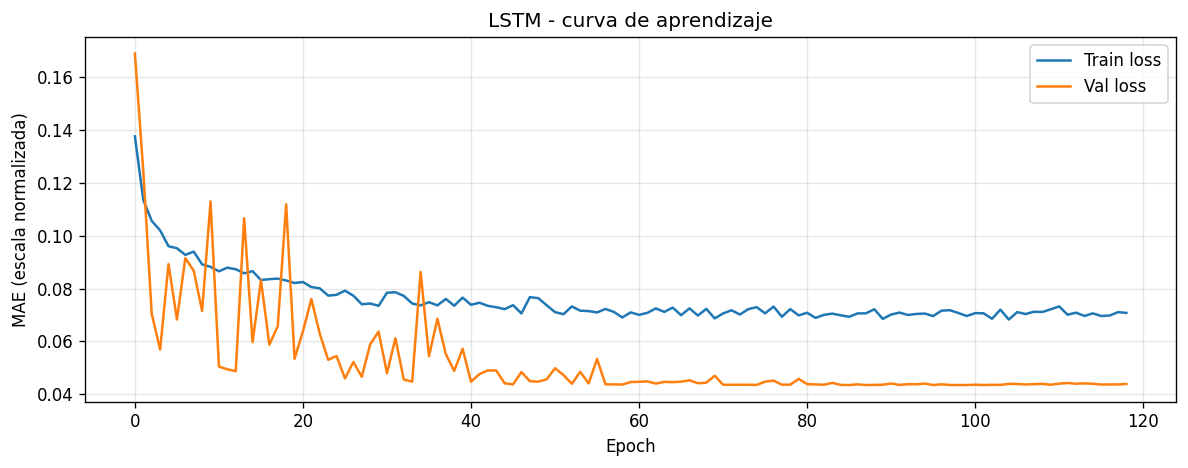

In [49]:
# Hiperparametros del create_model tomados de la busqueda. Editalos y reejecuta
# SOLO esta celda para probar variantes sin repetir el GridSearchCV.
PARAMS_LSTM = {k.replace('model__', ''): v for k, v in best_params_lstm.items()
               if k.startswith('model__')}
BATCH_LSTM = best_params_lstm['batch_size']

tf.keras.utils.set_random_seed(42)
model_lstm = create_model(input_shape=(WINDOW, len(LSTM_FEATURES)), **PARAMS_LSTM)
model_lstm.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5),
]
history = model_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=200, batch_size=BATCH_LSTM,
    callbacks=callbacks, verbose=1,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Val loss')
ax.set_title('LSTM - curva de aprendizaje')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE (escala normalizada)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


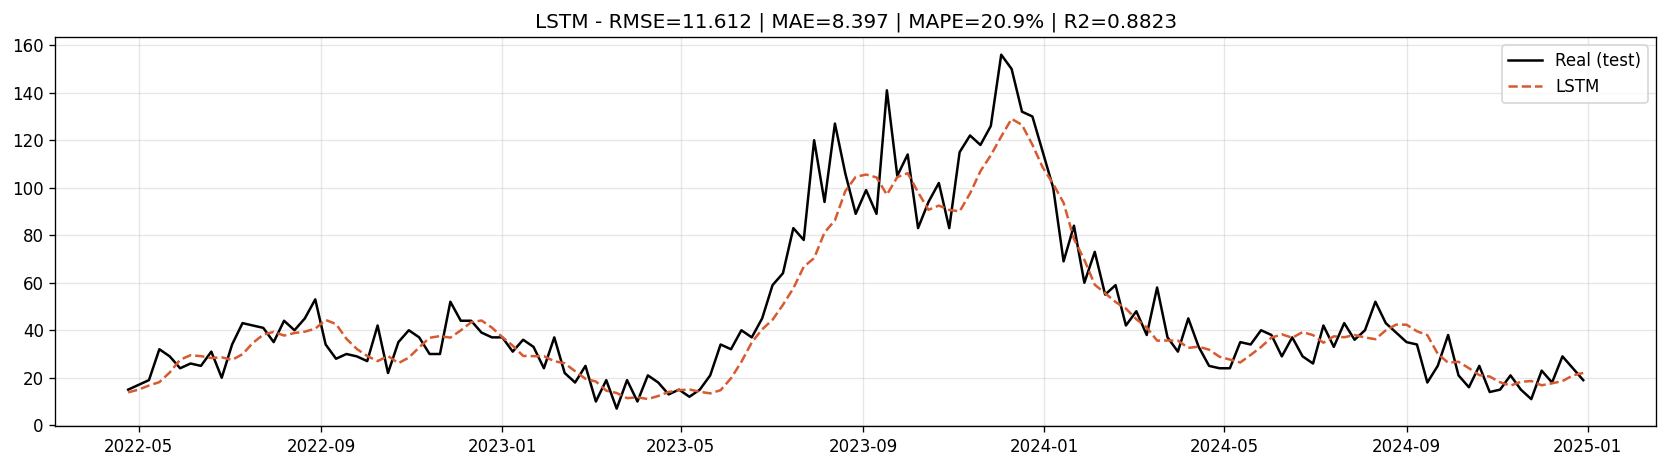

LSTM                                RMSE=  11.61 | MAE=  8.40 | MAPE= 20.90% | R2=0.8823


In [50]:
with mlflow.start_run(run_name='LSTM'):
    pred_lstm_scaled = model_lstm.predict(X_te).flatten()
    pred_lstm = inverse_casos(pred_lstm_scaled)
    real_lstm = inverse_casos(y_te)

    m_lstm = compute_metrics(real_lstm, pred_lstm)

    mlflow.log_params({
        'window': WINDOW, **PARAMS_LSTM, 'batch_size': BATCH_LSTM,
        'features': str(LSTM_FEATURES), 'preproc': 'log1p->minmax',
        'seleccion': 'GridSearchCV+TimeSeriesSplit', 'escala': 'departamental',
    })
    mlflow.log_metrics(m_lstm)
    mlflow.log_metric('epochs_trained', len(history.history['loss']))

    fechas_test_lstm = df_scaled.index[pos_test:]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fechas_test_lstm[:len(real_lstm)], real_lstm, color='black', label='Real (test)')
    ax.plot(fechas_test_lstm[:len(pred_lstm)], pred_lstm, color='#D85A30', linestyle='--', label='LSTM')
    ax.set_title(f'LSTM - RMSE={m_lstm["RMSE"]} | MAE={m_lstm["MAE"]} | MAPE={m_lstm["MAPE"]}% | R2={m_lstm["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'lstm_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('LSTM', m_lstm)

## 7.3 N-BEATS

N-BEATS (Neural Basis Expansion Analysis for Time Series) es una arquitectura de deep learning especifica para pronostico de series, basada en bloques apilados de capas densas que producen un componente de reconstruccion del pasado (backcast) y uno de pronostico (forecast). No es recurrente como LSTM; aprende expansiones de base que descomponen la señal, lo que suele dar buen desempeño en series univariadas con estacionalidad. Se implementa con la libreria darts, que ofrece N-BEATS listo y maneja internamente el escalado y el formato de ventana.

Se entrena sobre la serie de casos en escala logaritmica de train, reservando el bloque de validacion interno (FECHAS_VAL) para el early stopping, igual que LSTM. La evaluacion se hace un paso adelante (rolling one-step con historical_forecasts): en cada semana del test el modelo pronostica la siguiente usando la historia real observada, no sus propias predicciones. Asi la comparacion es justa frente a LSTM y los arboles, que tambien predicen a un paso. La prediccion se revierte con expm1 antes de calcular las metricas sobre el mismo 15 por ciento final de test.

In [33]:
serie_casos_log = np.log1p(df_dep.set_index('fecha_semana')['casos'])
ts_full = TimeSeries.from_series(serie_casos_log, freq='W-SUN')

fechas_orden_nb = df_dep.sort_values('fecha_semana')['fecha_semana']
n_train = fechas_orden_nb.isin(FECHAS_TRAIN).sum()
n_val = fechas_orden_nb.isin(FECHAS_VAL).sum()
ts_train = ts_full[:n_train]
ts_val = ts_full[n_train:n_train + n_val]
ts_test = ts_full[n_train + n_val:]
ts_trainval = ts_full[:n_train + n_val]



from darts.dataprocessing.transformers import Scaler
COV_VARS_NB = ['precipitacion', 'amplitud', 't2m_media']
cov_full = TimeSeries.from_dataframe(df_dep.sort_values('fecha_semana'), 'fecha_semana', COV_VARS_NB, freq='W-SUN')
cov_scaler = Scaler()
cov_scaler.fit(cov_full[:n_train])
cov_full_s = cov_scaler.transform(cov_full)

HORIZON_NB = 1
ACCEL_NB = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f'N-BEATS accelerator: {ACCEL_NB} (torch.cuda.is_available={torch.cuda.is_available()})')
print(f'Covariables pasadas: {COV_VARS_NB}')


def build_nbeats(input_chunk_length=16, num_blocks=1, layer_widths=256, n_epochs=200):
    early_stop = EarlyStoppingPL(monitor='val_loss', patience=20, min_delta=1e-4, mode='min')
    return NBEATSModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=HORIZON_NB,
        num_blocks=num_blocks,
        layer_widths=layer_widths,
        n_epochs=n_epochs,
        batch_size=16,
        random_state=42,
        pl_trainer_kwargs={'enable_progress_bar': False, 'accelerator': ACCEL_NB,
                           'devices': 1, 'callbacks': [early_stop]},
    )


N-BEATS accelerator: gpu (torch.cuda.is_available=True)
Covariables pasadas: ['precipitacion', 'amplitud', 't2m_media']


### Busqueda de hiperparametros (N-BEATS)

Grilla estilo diccionario (como el param_grid de los arboles): cada hiperparametro es una lista y ParameterGrid prueba todas las combinaciones. Cada config se entrena sobre el train interno y se evalua UN PASO ADELANTE sobre la validacion interna, sin tocar el test. Para agregar valores basta editar las listas y reejecutar solo esta celda.

In [51]:
NBEATS_GRID = {
    'input_chunk_length': [12, 26],
    'num_blocks': [1],
    'layer_widths': [128],
}

filas_nb = []
for params in ParameterGrid(NBEATS_GRID):
    m = build_nbeats(**params, n_epochs=150)
    m.fit(ts_train, past_covariates=cov_full_s,
          val_series=ts_val, val_past_covariates=cov_full_s, verbose=False)
    pred_val = m.historical_forecasts(
        series=ts_trainval, past_covariates=cov_full_s, start=n_train, start_format='position',
        forecast_horizon=1, stride=1, retrain=False, last_points_only=True, verbose=False)
    real_v = np.expm1(ts_val.slice_intersect(pred_val).values().flatten()).clip(min=0)
    pred_v = np.expm1(pred_val.slice_intersect(ts_val).values().flatten()).clip(min=0)
    filas_nb.append({**params,
                     'val_RMSE': round(float(np.sqrt(mean_squared_error(real_v, pred_v))), 3)})

df_nbeats_search = pd.DataFrame(filas_nb).sort_values('val_RMSE').reset_index(drop=True)
print(df_nbeats_search.to_string(index=False))
best_row_nb = df_nbeats_search.iloc[0]
best_params_nbeats = {k: int(best_row_nb[k]) for k in NBEATS_GRID}
print('Mejores hiperparametros N-BEATS:', best_params_nbeats)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


 input_chunk_length  layer_widths  num_blocks  val_RMSE
                 12           128           1    10.253
                 26           128           1    10.770
Mejores hiperparametros N-BEATS: {'input_chunk_length': 12, 'num_blocks': 1, 'layer_widths': 128}


### Entrenamiento y evaluacion final (N-BEATS)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


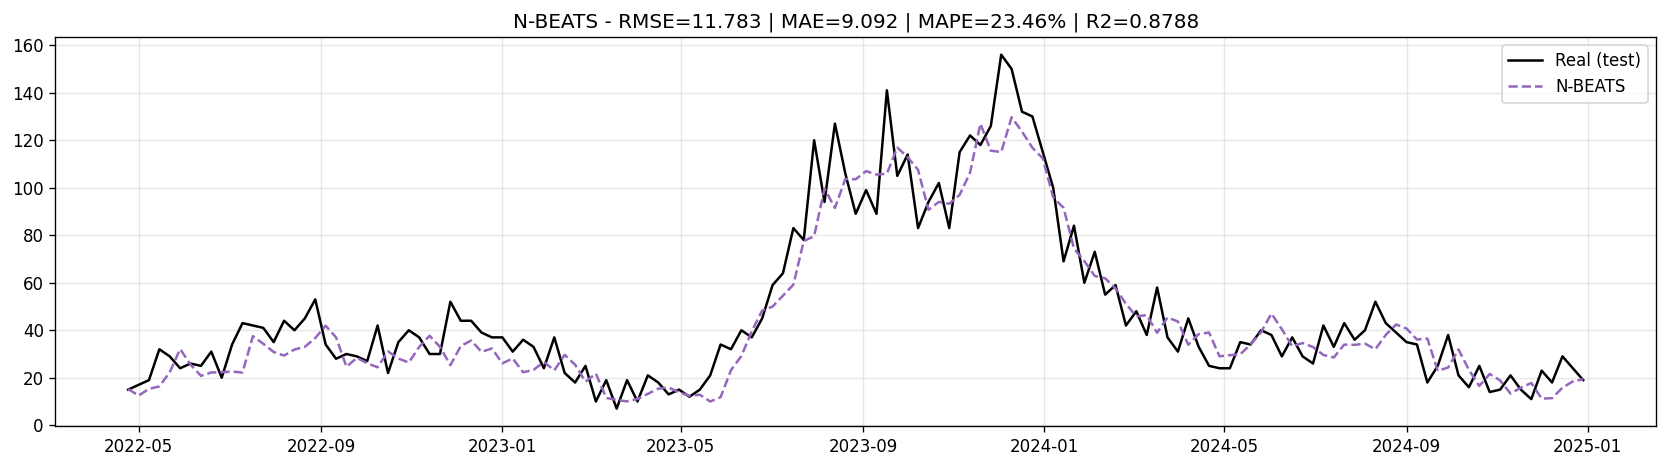

N-BEATS                             RMSE=  11.78 | MAE=  9.09 | MAPE= 23.46% | R2=0.8788


In [52]:
PARAMS_NBEATS = dict(best_params_nbeats)

with mlflow.start_run(run_name='N-BEATS'):
    model_nbeats = build_nbeats(**PARAMS_NBEATS, n_epochs=200)
    model_nbeats.fit(ts_train, past_covariates=cov_full_s,
                     val_series=ts_val, val_past_covariates=cov_full_s, verbose=False)

    pred_ts = model_nbeats.historical_forecasts(
        series=ts_full, past_covariates=cov_full_s, start=n_train + n_val, start_format='position',
        forecast_horizon=HORIZON_NB, stride=1, retrain=False,
        last_points_only=True, verbose=False)

    pred_al = pred_ts.slice_intersect(ts_test)
    real_al = ts_test.slice_intersect(pred_ts)
    pred_nbeats = np.expm1(pred_al.values().flatten()).clip(min=0)
    real_nbeats = np.expm1(real_al.values().flatten()).clip(min=0)

    m_nbeats = compute_metrics(real_nbeats, pred_nbeats)
    mlflow.log_params({
        **PARAMS_NBEATS, 'output_chunk_length': HORIZON_NB,
        'n_epochs': 200, 'batch_size': 16, 'escala_entrenamiento': 'log1p',
        'past_covariates': ','.join(COV_VARS_NB),
        'evaluacion': 'rolling one-step (historical_forecasts)',
        'accelerator': ACCEL_NB, 'lib': 'darts', 'escala': 'departamental',
    })
    mlflow.log_metrics(m_nbeats)

    fechas_test_nb = pred_al.time_index
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fechas_test_nb, real_nbeats, color='black', label='Real (test)')
    ax.plot(fechas_test_nb, pred_nbeats, color='#9467bd', linestyle='--', label='N-BEATS')
    ax.set_title(f'N-BEATS - RMSE={m_nbeats["RMSE"]} | MAE={m_nbeats["MAE"]} | MAPE={m_nbeats["MAPE"]}% | R2={m_nbeats["R2"]}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUTS / 'nbeats_pred.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()

print_metrics('N-BEATS', m_nbeats)


# 8 Comparación de modelos


Modelo,Familia,RMSE,MAE,MAPE,R2
LSTM,Deep Learning,11.61,8.40,20.90%,0.882
N-BEATS,Deep Learning,11.78,9.09,23.46%,0.879
LightGBM,Gradient Boosting,11.96,8.82,24.01%,0.875
Prophet (Prophet-AR-clima-p+amplitud),Estadistico,12.08,8.79,22.81%,0.873
XGBoost,Gradient Boosting,12.18,9.04,23.67%,0.871
SARIMAX (SARIMAX_PRECIPITACION_LOG_T2M_MEDIA_DIFF),Estadistico,12.56,9.34,23.65%,0.862


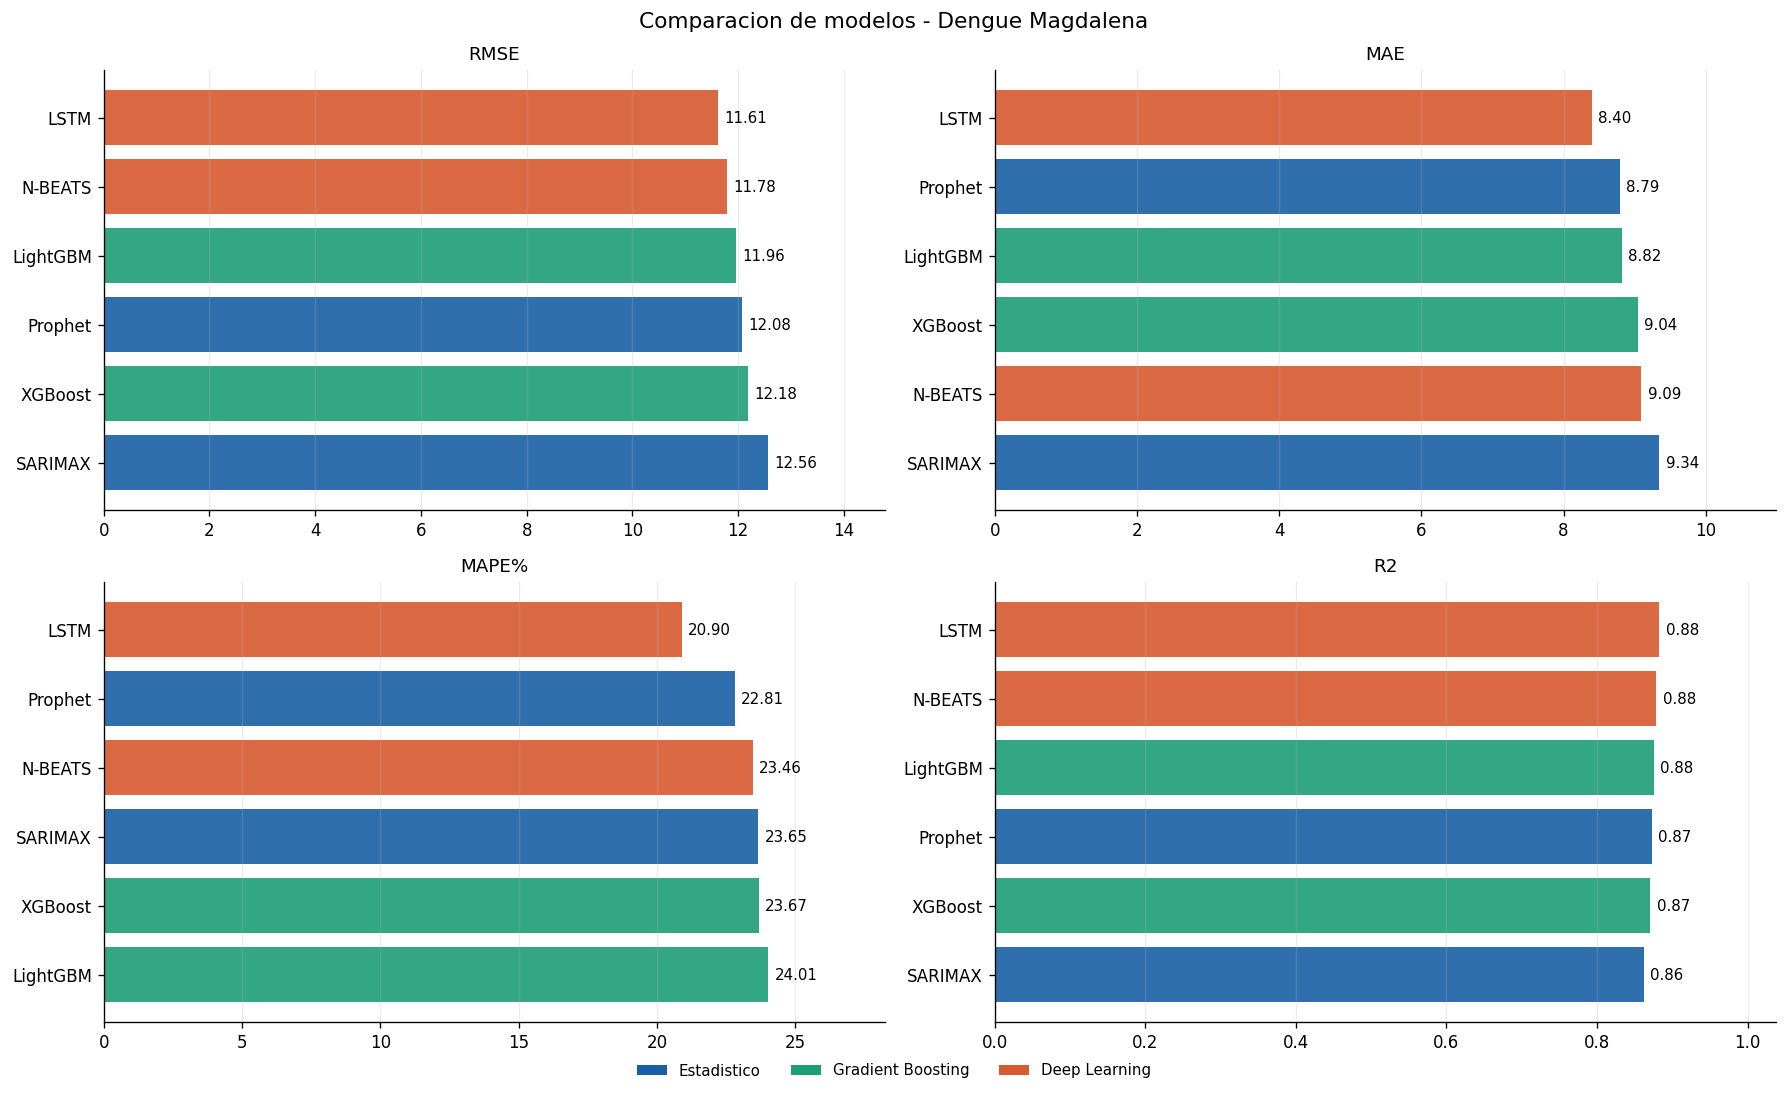

In [68]:
mejor_nombre_sarimax = min(resultados_sarimax, key=lambda k: resultados_sarimax[k]['RMSE'])
m_sarimax = resultados_sarimax[mejor_nombre_sarimax]
mejor_nombre_prophet = min(resultados_prophet, key=lambda k: resultados_prophet[k]['RMSE'])
m_prophet = resultados_prophet[mejor_nombre_prophet]
metricas_modelos = [
    (f'SARIMAX ({mejor_nombre_sarimax})', 'Estadistico',       'Departamental', m_sarimax),
    (f'Prophet ({mejor_nombre_prophet})', 'Estadistico',       'Departamental', m_prophet),
    ('XGBoost',                           'Gradient Boosting', 'Departamental', m_xgb),
    ('LightGBM',                          'Gradient Boosting', 'Departamental', m_lgbm),
    ('LSTM',                              'Deep Learning',     'Departamental', m_lstm),
    ('N-BEATS',                           'Deep Learning',     'Departamental', m_nbeats),
]

resultados = pd.DataFrame([
    {'Modelo': nombre, 'Familia': familia, 'Escala': escala, **m}
    for nombre, familia, escala, m in metricas_modelos
]).sort_values('RMSE').reset_index(drop=True)

colores_familia = {'Estadistico': '#185FA5', 'Gradient Boosting': '#1D9E75', 'Deep Learning': '#D85A30'}

def _color_familia(s):
    return [f'color: {colores_familia[v]}; font-weight: 600' for v in s]

tabla = resultados[['Modelo', 'Familia', 'RMSE', 'MAE', 'MAPE', 'R2']]
styled = (tabla.style
    .format({'RMSE': '{:.2f}', 'MAE': '{:.2f}', 'MAPE': '{:.2f}%', 'R2': '{:.3f}'})
    .hide(axis='index')
    .apply(_color_familia, subset=['Familia'])
    .highlight_min(subset=['RMSE', 'MAE', 'MAPE'], color="#e5f5e06d")
    .highlight_max(subset=['R2'], color="#e5f5e06d")
    .set_caption('Comparación de modelos - Dengue Magdalena')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', '600'), ('padding', '6px')]},
        {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '4px 10px')]},
        {'selector': 'td', 'props': [('padding', '4px 10px')]},
    ]))
display(styled)

# Barras: nombre corto, de mejor (arriba) a peor, color por familia.
resultados['corto'] = resultados['Modelo'].str.split('(').str[0].str.strip()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, metrica in zip(axes.flat, ['RMSE', 'MAE', 'MAPE', 'R2']):
    df_plot = resultados.sort_values(metrica, ascending=(metrica == 'R2'))  # mejor arriba
    colors = [colores_familia[f] for f in df_plot['Familia']]
    bars = ax.barh(df_plot['corto'], df_plot[metrica], color=colors, alpha=0.9)
    for bar, v in zip(bars, df_plot[metrica]):
        ax.text(v + abs(v) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.2f}', va='center', fontsize=9)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.12)
    if metrica == 'R2':
        ax.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_title(f'{metrica}{"%" if metrica == "MAPE" else ""}', fontsize=11)
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

leyenda = [Patch(facecolor=c, label=f) for f, c in colores_familia.items()]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Comparacion de modelos - Dengue Magdalena', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


# 9 Evaluación multi-paso: horizontes de 2, 4 y 8 semanas

Las metricas de la sección 8 son a un paso: cada prediccion usa los casos reales de las semanas previas y por eso aprovechan la fuerte autocorrelacion semanal de la serie (lag-1 cercano a 0.93). Eso es un nowcast, no un pronostico anticipado.

Aqui se reevaluan los mismos modelos como pronostico multi-paso real con origen movil (walk-forward): desde cada semana de origen se pronostican las 8 semanas siguientes sin ver los casos intermedios, y para los horizontes h = 1, 2, 4 y 8 se comparan las predicciones con los casos reales sobre todo el test. Los modelos autorregresivos (SARIMAX, Prophet, arboles, LSTM) realimentan sus propias predicciones de forma recursiva; N-BEATS pronostica recursivamente via historical_forecasts.

El clima se entrega como covariable observada (conocida a futuro), una suposicion generosa que aisla la perdida de la senal autorregresiva. Se incluye una linea base de persistencia (el pronostico es el ultimo valor observado) para juzgar si los modelos aportan algo sobre no hacer nada. El horizonte h = 1 se muestra como referencia y reproduce la seccion 8.

## 9.1 Andamiaje de evaluacion y lineas base


In [69]:
HORIZONTES = [1, 2, 4, 6, 8]
H_MAX = max(HORIZONTES)

# Todo se evalua sobre el calendario semanal completo, alineado por fecha.
serie_casos_ms = df_dep.set_index('fecha_semana')['casos'].sort_index()
fechas_ms = list(serie_casos_ms.index)
N_ms = len(fechas_ms)
casos_ms = serie_casos_ms.values.astype(float)
casos_log_ms = np.log1p(casos_ms)
clima_ms = {v: serie_casos_ms.index.to_series().map(
                df_dep.set_index('fecha_semana')[v]).values.astype(float)
            for v in CLIMA_VARS}

pos_test_ms = {fechas_ms.index(d) for d in FECHAS_TEST}
first_test_ms, last_test_ms = min(pos_test_ms), max(pos_test_ms)
O_MIN = max(first_test_ms - H_MAX, 60)   # origenes que cubren todos los targets de test


def evaluar_multistep(path_fn):
    # path_fn(o) -> np.array de largo H_MAX: prediccion a 1..H_MAX pasos (escala real).
    buckets = {h: ([], []) for h in HORIZONTES}
    for o in range(O_MIN, last_test_ms):
        path = path_fn(o)
        for h in HORIZONTES:
            tp = o + h
            if tp > last_test_ms or tp not in pos_test_ms:
                continue
            buckets[h][0].append(casos_ms[tp])
            buckets[h][1].append(path[h - 1])
    return {h: compute_metrics(np.asarray(y), np.asarray(yh)) for h, (y, yh) in buckets.items()}


# Lineas base sin modelo.
def path_persistencia(o):
    return np.full(H_MAX, casos_ms[o], dtype=float)          # y(o+h) = y(o)

print(f'Origenes de evaluacion: {O_MIN}..{last_test_ms - 1} | horizontes: {HORIZONTES}')

Origenes de evaluacion: 791..938 | horizontes: [1, 2, 4, 6, 8]


## 9.2 Funciones de pronostico multi-paso por modelo


In [70]:
# --- Arboles (XGBoost, LightGBM): recursivo. Reconstruye TODAS las features con build_features
# sobre las predicciones realimentadas, para que lags, medias moviles y sin/cos sean identicos
# a los del entrenamiento. Robusto a cualquier feature nueva de build_features.
_arbol_base = df_dep.sort_values('fecha_semana')[['fecha_semana', 'casos'] + CLIMA_VARS].reset_index(drop=True)

def _path_arbol(modelo):
    def pf(o):
        work = _arbol_base.copy()
        work.loc[work.index > o, 'casos'] = np.nan        # ocultar los casos reales del futuro
        out = np.full(H_MAX, np.nan)
        for k in range(1, H_MAX + 1):
            tp = o + k
            if tp >= N_ms:
                continue
            work.loc[tp, 'casos'] = 0.0                    # placeholder: no se usa como feature de su propia fila
            feats = build_features(work.iloc[:tp + 1])
            x = feats.iloc[[-1]][FEATURE_COLS]             # ultima fila = semana objetivo tp
            yh = max(float(modelo.predict(x)[0]), 0.0)
            work.loc[tp, 'casos'] = yh                     # realimenta la prediccion para los pasos siguientes
            out[k - 1] = yh
        return out
    return pf

path_xgb_ms = _path_arbol(xgb)
path_lgbm_ms = _path_arbol(lgbm)


# --- LSTM: recursivo deslizando la ventana (sin cambios) ---
_feats_lstm = df_scaled.reindex(fechas_ms)[LSTM_FEATURES].values.astype('float32')  # casos en col 0 (log)
_lstm_fast = tf.function(lambda x: model_lstm(x, training=False))

def path_lstm_ms(o):
    win = _feats_lstm[o - WINDOW + 1:o + 1].copy()
    escal = np.full(H_MAX, np.nan)
    for k in range(1, H_MAX + 1):
        tp = o + k
        if tp >= N_ms:
            continue
        ys = float(_lstm_fast(win[None, ...]).numpy().ravel()[0])
        escal[k - 1] = ys
        nrow = _feats_lstm[tp].copy()
        nrow[0] = ys
        win = np.vstack([win[1:], nrow])
    out = np.full(H_MAX, np.nan)
    m = ~np.isnan(escal)
    if m.any():
        out[m] = inverse_casos(escal[m])
    return out


In [71]:
# --- SARIMAX: refit del mejor config de la seccion 6 y pronostico recursivo ---
def _exog_sarimax(v, s):
    if v == 'precipitacion_log':
        return np.log1p(s['precipitacion'])
    if v.endswith('_diff'):
        return s[v.replace('_diff', '')].diff()
    return s[v]

_best_sx_exog = next((ev for ev in combinaciones_exog
                      if nombre_run_sarimax(ev) == mejor_nombre_sarimax), [])
_sx_base = df_dep.set_index('fecha_semana').sort_index()
_sx_cols = [f'{v}_lag{l}' for v in _best_sx_exog for l in LAGS_CLIMA]
for v in _best_sx_exog:
    base_v = _exog_sarimax(v, _sx_base)
    for l in LAGS_CLIMA:
        _sx_base[f'{v}_lag{l}'] = base_v.shift(l)
_sx_y = np.log1p(_sx_base['casos'])
_sx_X = _sx_base[_sx_cols] if _sx_cols else None
_sx_start = int(np.where(~_sx_X.isna().any(axis=1).values)[0][0]) if _sx_cols else 0

_sx_mask_tv = _sx_y.iloc[_sx_start:].index.isin(FECHAS_TRAINVAL)
_sx_fit0 = SARIMAX(
    _sx_y.iloc[_sx_start:][_sx_mask_tv],
    exog=(_sx_X.iloc[_sx_start:][_sx_mask_tv].values if _sx_cols else None),
    order=ORDER, seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def path_sarimax_ms(o):
    endog = _sx_y.iloc[_sx_start:o + 1]
    exog = _sx_X.iloc[_sx_start:o + 1].values if _sx_cols else None
    res = _sx_fit0.apply(endog, exog=exog, refit=False)
    steps = min(H_MAX, N_ms - 1 - o)
    fut = _sx_X.iloc[o + 1:o + 1 + steps].values if _sx_cols else None
    fc = res.get_forecast(steps=steps, exog=fut).predicted_mean
    out = np.full(H_MAX, np.nan)
    out[:steps] = np.expm1(np.asarray(fc)).clip(min=0)
    return out

print(f'SARIMAX multi-paso: exog={_best_sx_exog or "ninguna"} | order={ORDER} seasonal={SEASONAL_ORDER}')

SARIMAX multi-paso: exog=['precipitacion_log', 't2m_media_diff'] | order=(2, 1, 2) seasonal=(0, 0, 0, 52)


In [72]:
# --- Prophet: refit del mejor config de la seccion 6 y pronostico recursivo con realimentacion AR ---
_ph_map = {'Prophet-solo': ([], False), 'Prophet-AR': ([], True)}
_ph_map.update({k: (v, True) for k, v in combinaciones_prophet.items()})
_best_ph_exog, _best_ph_ar = _ph_map.get(mejor_nombre_prophet, ([], True))

_ph_base = df_dep.set_index('fecha_semana').sort_index().copy()
_ph_base['precipitacion_log'] = np.log1p(_ph_base['precipitacion'])
_ph_base['casos_log'] = np.log1p(_ph_base['casos'])
_ph_ar_cols = [f'casos_lag{l}_log' for l in LAGS_TARGET] if _best_ph_ar else []
for l in LAGS_TARGET:
    _ph_base[f'casos_lag{l}_log'] = _ph_base['casos_log'].shift(l)
_ph_clima_cols = [f'{v}_lag{l}' for v in _best_ph_exog for l in LAGS_CLIMA]
for v in _best_ph_exog:
    for l in LAGS_CLIMA:
        _ph_base[f'{v}_lag{l}'] = _ph_base[v].shift(l)
_ph_reg = _ph_ar_cols + _ph_clima_cols

_ph_tv = _ph_base[_ph_base.index.isin(FECHAS_TRAINVAL)]
if _ph_reg:
    _ph_tv = _ph_tv.dropna(subset=_ph_reg)
_dtr = _ph_tv.reset_index()[['fecha_semana', 'casos_log'] + _ph_reg].rename(
    columns={'fecha_semana': 'ds', 'casos_log': 'y'})
_ph_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
for c in _ph_reg:
    _ph_model.add_regressor(c)
_ph_model.fit(_dtr)

_ph_clima_arr = {c: _ph_base[c].values for c in _ph_clima_cols}

def path_prophet_ms(o):
    histlog = {p: casos_log_ms[p] for p in range(o - max(LAGS_TARGET), o + 1)}
    out = np.full(H_MAX, np.nan)
    for k in range(1, H_MAX + 1):
        tp = o + k
        if tp >= N_ms:
            continue
        fila = {'ds': fechas_ms[tp]}
        if _best_ph_ar:
            for l in LAGS_TARGET:
                fila[f'casos_lag{l}_log'] = histlog[tp - l]
        for c in _ph_clima_cols:
            fila[c] = _ph_clima_arr[c][tp]
        yhl = float(_ph_model.predict(pd.DataFrame([fila]))['yhat'].iloc[0])
        histlog[tp] = yhl
        out[k - 1] = max(np.expm1(yhl), 0.0)
    return out

print(f'Prophet multi-paso: {mejor_nombre_prophet} | AR={_best_ph_ar} exog={_best_ph_exog or "ninguna"}')

17:31:08 - cmdstanpy - INFO - Chain [1] start processing
17:31:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet multi-paso: Prophet-AR-clima-p+amplitud | AR=True exog=['precipitacion_log', 'amplitud']


In [73]:
# --- N-BEATS: recursivo por horizonte con historical_forecasts (eficiente) ---
_n_train_ms = pd.Index(fechas_ms).isin(FECHAS_TRAIN).sum()
_n_val_ms = pd.Index(fechas_ms).isin(FECHAS_VAL).sum()
_nb_start = int(_n_train_ms + _n_val_ms - H_MAX)

def evaluar_nbeats():
    salida = {}
    for h in HORIZONTES:
        hf = model_nbeats.historical_forecasts(
            series=ts_full, past_covariates=cov_full_s, start=_nb_start, start_format='position',
            forecast_horizon=h, stride=1, retrain=False,
            last_points_only=True, verbose=False)
        s = pd.Series(np.expm1(hf.values().flatten()).clip(min=0), index=hf.time_index)
        s = s[[d in FECHAS_TEST for d in s.index]]
        y = serie_casos_ms.reindex(s.index).values
        salida[h] = compute_metrics(y, s.values)
    return salida


## 9.3 Resultados por horizonte


In [74]:
resultados_ms = {
    'SARIMAX':          evaluar_multistep(path_sarimax_ms),
    'Prophet':          evaluar_multistep(path_prophet_ms),
    'XGBoost':          evaluar_multistep(path_xgb_ms),
    'LightGBM':         evaluar_multistep(path_lgbm_ms),
    'LSTM':             evaluar_multistep(path_lstm_ms),
    'N-BEATS':          evaluar_nbeats(),
    'Persistencia':     evaluar_multistep(path_persistencia),
}

df_ms = pd.DataFrame([
    {'Modelo': modelo, 'H (sem)': h, **resultados_ms[modelo][h]}
    for modelo in resultados_ms for h in HORIZONTES
])


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (cuda), used: True
TPU a

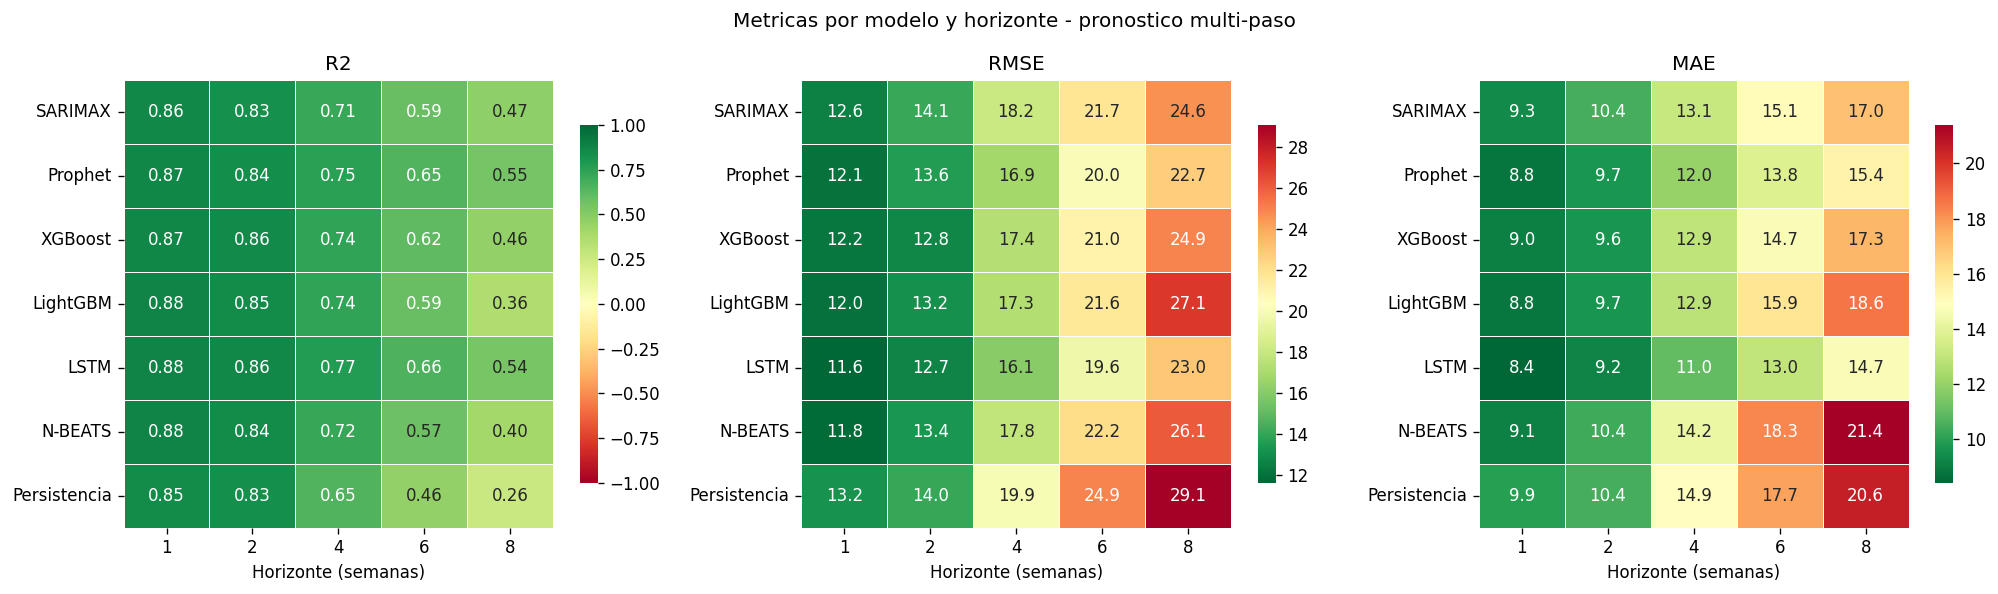

In [75]:
ORDEN_MS = ['SARIMAX', 'Prophet', 'XGBoost', 'LightGBM', 'LSTM', 'N-BEATS', 'Persistencia']

# (metrica, cmap, formato, center, vmin, vmax). R2: verde=alto; RMSE/MAE: verde=bajo (cmap invertido).
specs = [
    ('R2',   'RdYlGn',   '.2f',    0,   -1,   1),
    ('RMSE', 'RdYlGn_r', '.1f', None, None, None),
    ('MAE',  'RdYlGn_r', '.1f', None, None, None),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (metrica, cmap, fmt, center, vmin, vmax) in zip(axes, specs):
    mat = df_ms.pivot(index='Modelo', columns='H (sem)', values=metrica).reindex(ORDEN_MS)
    sns.heatmap(mat, ax=ax, annot=True, fmt=fmt, cmap=cmap, center=center, vmin=vmin, vmax=vmax,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(metrica)
    ax.set_xlabel('Horizonte (semanas)')
    ax.set_ylabel('')
plt.suptitle('Metricas por modelo y horizonte - pronostico multi-paso', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'multistep_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


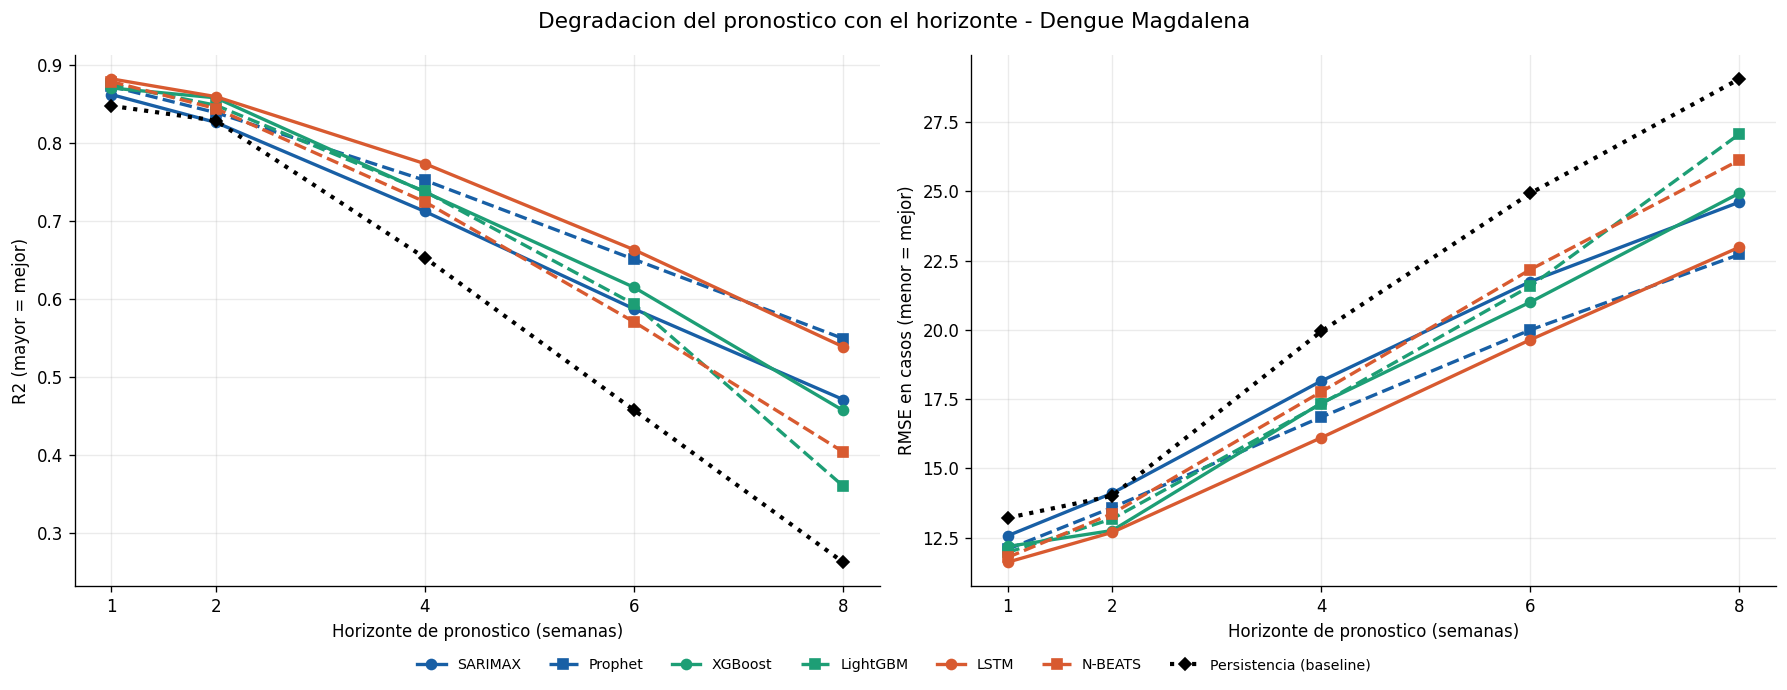

In [76]:
# Color por familia; dentro de cada familia, linea solida vs punteada para distinguir los dos modelos.
ESTILO_MS = {
    'SARIMAX':  ('#185FA5', '-',  'o'), 'Prophet':  ('#185FA5', '--', 's'),
    'XGBoost':  ('#1D9E75', '-',  'o'), 'LightGBM': ('#1D9E75', '--', 's'),
    'LSTM':     ('#D85A30', '-',  'o'), 'N-BEATS':  ('#D85A30', '--', 's'),
}
ETIQUETA_Y = {'R2': 'R2 (mayor = mejor)', 'RMSE': 'RMSE en casos (menor = mejor)'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, metrica in zip(axes, ['R2', 'RMSE']):
    for modelo, (color, ls, mk) in ESTILO_MS.items():
        vals = [resultados_ms[modelo][h][metrica] for h in HORIZONTES]
        ax.plot(HORIZONTES, vals, ls=ls, marker=mk, color=color, linewidth=2, markersize=6, label=modelo)
    base = [resultados_ms['Persistencia'][h][metrica] for h in HORIZONTES]
    ax.plot(HORIZONTES, base, color='black', ls=':', linewidth=2.5, marker='D', markersize=5,
            label='Persistencia (baseline)')
    ax.set_xlabel('Horizonte de pronostico (semanas)')
    ax.set_ylabel(ETIQUETA_Y[metrica])
    ax.set_xticks(HORIZONTES)
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

# Panel R2: linea de skill nulo y sombreado de la zona "peor que la media".
ax0 = axes[0]

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Degradacion del pronostico con el horizonte - Dengue Magdalena', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'multistep_horizontes.png', dpi=150, bbox_inches='tight')
plt.show()
